# Factorial Experiment — Results Visualizations

Reads the aggregated outputs from `dl_08_aggregate_factorial.py`
(`Models/factorial_results/analysis/`) plus the per-cell SHAP JSONs written by
`dl_09_shap_factorial.py`, and renders the headline figures:

1. **Overall metrics** — accuracy, macro-F1, mean-IoU per config (± seed sd)
2. **Per-class metrics** — recall / F1 / IoU per class, per config (+ heatmaps)
3. **Confusion matrices** — seed-mean, raw counts and row-normalized (%)
4. **SHAP feature importance** — per model, averaged across seeds (overall + per-class)
5. **Extras** — contrasts forest plot (the actual scientific story), seed-variability
   strips, and the SHAP-reliance vs ablation-gain pairing

Everything is read-only and tolerant of a partial tree, so it is safe to re-run
while more cells are still finishing. Configure paths in the **Setup** cell.


In [10]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# seaborn drives every heatmap / confusion matrix. Self-heal if the active
# kernel doesn't have it (this repo has several Python envs floating around).
try:
    import seaborn as sns
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "seaborn"])
    import seaborn as sns
sns.set_style("whitegrid")

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150,
    "axes.grid": True, "grid.alpha": 0.3,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})

# --- Experiment version + classification mode selectors ----------------------
# EXP_VERSION suffixes every results root (EXECUTION.md §11): "" = base factorial
# (Models/factorial_results, results_patchcurve, ...); "v2" -> the _v2 roots.
# MODE picks the classification axis. v2 nests a <mode> level under each results
# root (factorial_results_v2/<mode>/...); v1 has no such level. Both read from
# the env so the notebook can be pointed at a version/mode without editing code.
EXP_VERSION = os.environ.get("EXP_VERSION", "v2")   # "" = base; "v2", "v3", ...
MODE        = os.environ.get("MODE", "binary")  # "multiclass" | "binary"
_SUFFIX = f"_{EXP_VERSION}" if EXP_VERSION else ""

def find_models_dir() -> Path:
    """Locate the Models/ dir holding factorial_results{_SUFFIX}, cwd-agnostic."""
    here = Path.cwd()
    for base in [here, *here.parents]:
        cand = base / "Models"
        if (cand / f"factorial_results{_SUFFIX}").is_dir():
            return cand
    cand = Path("/ibstorage/anthony/NYS_Wetlands_DL/Models")
    if (cand / f"factorial_results{_SUFFIX}").is_dir():
        return cand
    raise FileNotFoundError(f"Could not locate Models/factorial_results{_SUFFIX}")

MODELS_DIR = find_models_dir()
_FACT_ROOT = MODELS_DIR / f"factorial_results{_SUFFIX}"
# v2 inserts a <mode> level under each results root; v1 has none. Detect it so
# the same notebook drives both layouts. MODE_LEVEL is "" when there is no such
# level (v1), otherwise the resolved mode dir name.
MODE_LEVEL = MODE if (_FACT_ROOT / MODE).is_dir() else ""
RESULTS_DIR  = _FACT_ROOT / MODE_LEVEL if MODE_LEVEL else _FACT_ROOT
ANALYSIS_DIR = RESULTS_DIR / "analysis"
FIG_DIR = ANALYSIS_DIR / "figures"      # PNGs are saved here for the write-up
FIG_DIR.mkdir(exist_ok=True, parents=True)

def with_mode(p: Path) -> Path:
    """Append the resolved <mode> level to a sibling results root (no-op on v1)."""
    return p / MODE_LEVEL if MODE_LEVEL else p

print("version :", EXP_VERSION or "(base)")
print("mode    :", MODE_LEVEL or "(no mode level / v1)")
print("results :", RESULTS_DIR)
print("analysis:", ANALYSIS_DIR)
print("figures :", FIG_DIR)


def _scores(metrics: dict) -> dict:
    """Score block of a metrics.json, schema-agnostic. v2 (run_config.sh) nests
    scores under 'test_metrics'; v1 (dl_05) wrote them flat. Mirrors the unwrap
    in dl_08_aggregate_factorial.py so every raw metrics.json reader here agrees."""
    return metrics.get("test_metrics") or metrics


# --- Canonical ordering / labels (from dl_experiment_config, the source of truth) --
# Derive CONFIG_ORDER from the registry so a matrix change here needs no edit.
# Falls back to the hardcoded v2 order if the import is unavailable (e.g. a
# kernel without rasterio, which dl_experiment_config imports transitively).
_V2_CONFIG_ORDER = [
    "fld_nolidar_leafon", "fld_nolidar_leafoff",
    "fld_chmret_leafon",  "fld_chmret_leafoff",
    "nwi_chmret_leafoff", "nwiextra_chmret_leafoff",
    "nwifield_chmret_leafoff", "flddeg_chmret_leafoff",
]
try:
    _PIPE = MODELS_DIR.parent / "Python_Code_Analysis" / "DL_Pipeline_v2"
    if str(_PIPE) not in sys.path:
        sys.path.insert(0, str(_PIPE))
    from dl_experiment_config import CONFIGS as _CONFIGS
    CONFIG_ORDER = list(_CONFIGS.keys())
except Exception as e:
    print(f"[config order] using hardcoded v2 order (registry import failed: {e})")
    CONFIG_ORDER = _V2_CONFIG_ORDER

# Class axis depends on the mode: binary collapses EMW/FSW/SSW -> WET.
if MODE_LEVEL == "binary":
    CLASS_ORDER = ["WET", "UPL"]
else:
    CLASS_ORDER = ["EMW", "FSW", "SSW", "UPL"]
CLASS_FULL = {"EMW": "Emergent", "FSW": "Forested", "SSW": "Scrub-Shrub",
              "UPL": "Upland", "WET": "Wetland"}

# A stable color per config and per class (used across every figure).
_cfg_cmap = plt.get_cmap("tab10")
CONFIG_COLORS = {c: _cfg_cmap(i % 10) for i, c in enumerate(CONFIG_ORDER)}
CLASS_COLORS = {"EMW": "#2ca02c", "FSW": "#1f77b4", "SSW": "#ff7f0e",
                "UPL": "#8c564b", "WET": "#2c7fb8"}

def order_configs(seq):
    """Keep CONFIG_ORDER, drop configs absent from `seq`, append any extras."""
    present = [c for c in CONFIG_ORDER if c in set(seq)]
    extra = [c for c in seq if c not in CONFIG_ORDER]
    return present + sorted(set(extra))

def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")


version : v2
mode    : binary
results : /ibstorage/anthony/NYS_Wetlands_DL/Models/factorial_results_v2/binary
analysis: /ibstorage/anthony/NYS_Wetlands_DL/Models/factorial_results_v2/binary/analysis
figures : /ibstorage/anthony/NYS_Wetlands_DL/Models/factorial_results_v2/binary/analysis/figures
[config order] using hardcoded v2 order (registry import failed: /local/workdir/ajs544/miniconda3/envs/geospatial-processing/lib/libsqlite3.so: cannot open shared object file: No such file or directory)


## Load the aggregated data

`factorial_long.csv` is the spine — one row per (config, seed, class). Cell-level
scalars (`overall_accuracy`, `macro_f1`, `mean_iou`) are repeated across that
cell's four class rows, so we `drop_duplicates("seed")` whenever we want one
value per (config, seed).

In [11]:
long = pd.read_csv(ANALYSIS_DIR / "factorial_long.csv")
summary = pd.read_csv(ANALYSIS_DIR / "factorial_summary.csv")
contrasts = pd.read_csv(ANALYSIS_DIR / "contrasts.csv")
coverage = pd.read_csv(ANALYSIS_DIR / "coverage.csv")

# Order config as an ordered categorical so every groupby/plot sorts the same.
present_cfgs = order_configs(long["config"].unique())
long["config"] = pd.Categorical(long["config"], categories=present_cfgs, ordered=True)

n_seeds = long.groupby("config", observed=True)["seed"].nunique()
print(f"Configs present : {len(present_cfgs)}")
print(f"Coverage        : {int(coverage['present'].sum())}/{len(coverage)} cells")
print("\nSeeds per config:")
print(n_seeds.to_string())

# Cell-level frame: one row per (config, seed) for the overall metrics.
cell = (long.drop_duplicates(["config", "seed"])
            .loc[:, ["config", "seed", "label", "lidar", "spectral", "featureset",
                     "overall_accuracy", "macro_f1", "macro_recall",
                     "macro_precision", "mean_iou", "in_channels"]]
            .reset_index(drop=True))
cell.head()


Configs present : 8
Coverage        : 40/40 cells

Seeds per config:
config
fld_nolidar_leafon         5
fld_nolidar_leafoff        5
fld_chmret_leafon          5
fld_chmret_leafoff         5
nwi_chmret_leafoff         5
nwiextra_chmret_leafoff    5
nwifield_chmret_leafoff    5
flddeg_chmret_leafoff      5


,config,seed,label,lidar,spectral,featureset,overall_accuracy,macro_f1,macro_recall,macro_precision,mean_iou,in_channels
0,fld_nolidar_leafon,0,fld,nolidar,leafon,nolidar_leafon,0.8550,0.8519,0.85640,0.84945,0.7426,18
1,fld_nolidar_leafon,1,fld,nolidar,leafon,nolidar_leafon,0.8526,0.8507,0.85225,0.84960,0.7406,18
2,fld_nolidar_leafon,2,fld,nolidar,leafon,nolidar_leafon,0.8252,0.8241,0.83150,0.82440,0.7011,18
3,fld_nolidar_leafon,3,fld,nolidar,leafon,nolidar_leafon,0.8377,0.7773,0.75950,0.80560,0.6505,18
4,fld_nolidar_leafon,4,fld,nolidar,leafon,nolidar_leafon,0.8751,0.8438,0.85895,0.83225,0.7362,18


## 1 · Overall model performance

Bars are the mean over seeds; error bars are ±1 sd across seeds (so they show the
seed-to-seed stability the factorial design is built to measure). The first six
configs are the field-label feature ablations; `nwi_*` and `flddeg_*` swap the
label source while holding the full feature set.

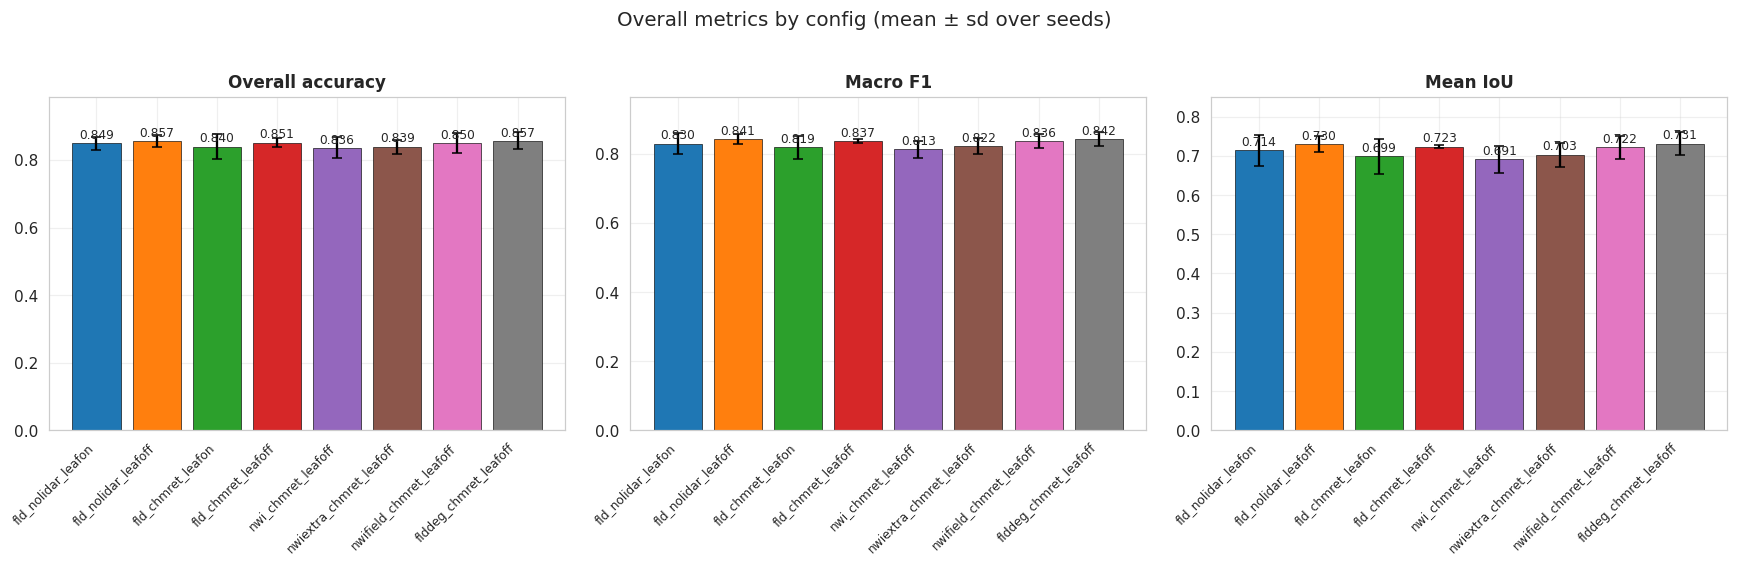

In [12]:
def mean_sd(frame, value, by="config"):
    g = frame.groupby(by, observed=True)[value]
    return g.mean(), g.std().fillna(0.0)

OVERALL_METRICS = [
    ("overall_accuracy", "Overall accuracy"),
    ("macro_f1",         "Macro F1"),
    ("mean_iou",         "Mean IoU"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
for ax, (col, title) in zip(axes, OVERALL_METRICS):
    m, s = mean_sd(cell, col)
    m = m.reindex(present_cfgs); s = s.reindex(present_cfgs)
    colors = [CONFIG_COLORS[c] for c in present_cfgs]
    ax.bar(range(len(m)), m.values, yerr=s.values, capsize=3,
           color=colors, edgecolor="black", linewidth=0.4)
    for i, v in enumerate(m.values):
        ax.text(i, v + 0.005, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(range(len(m)))
    ax.set_xticklabels(present_cfgs, rotation=45, ha="right", fontsize=8)
    ax.set_title(title)
    ax.set_ylim(0, min(1.0, (m + s).max() * 1.12))
fig.suptitle("Overall metrics by config (mean ± sd over seeds)", y=1.02, fontsize=13)
fig.tight_layout()
savefig(fig, "01_overall_metrics")
plt.show()


## 2 · Per-class performance

For semantic segmentation the per-class story is what matters — the headline is
whether below-canopy features rescue **FSW** (forested wetland) recall without
costing **UPL**. Note: per-class *recall* is the producer's accuracy (diagonal of
the row-normalized confusion matrix); *precision* is the user's accuracy.

Two views: grouped bars (class on x, config as the group) for each metric, and a
config × class heatmap for a compact all-in-one read.

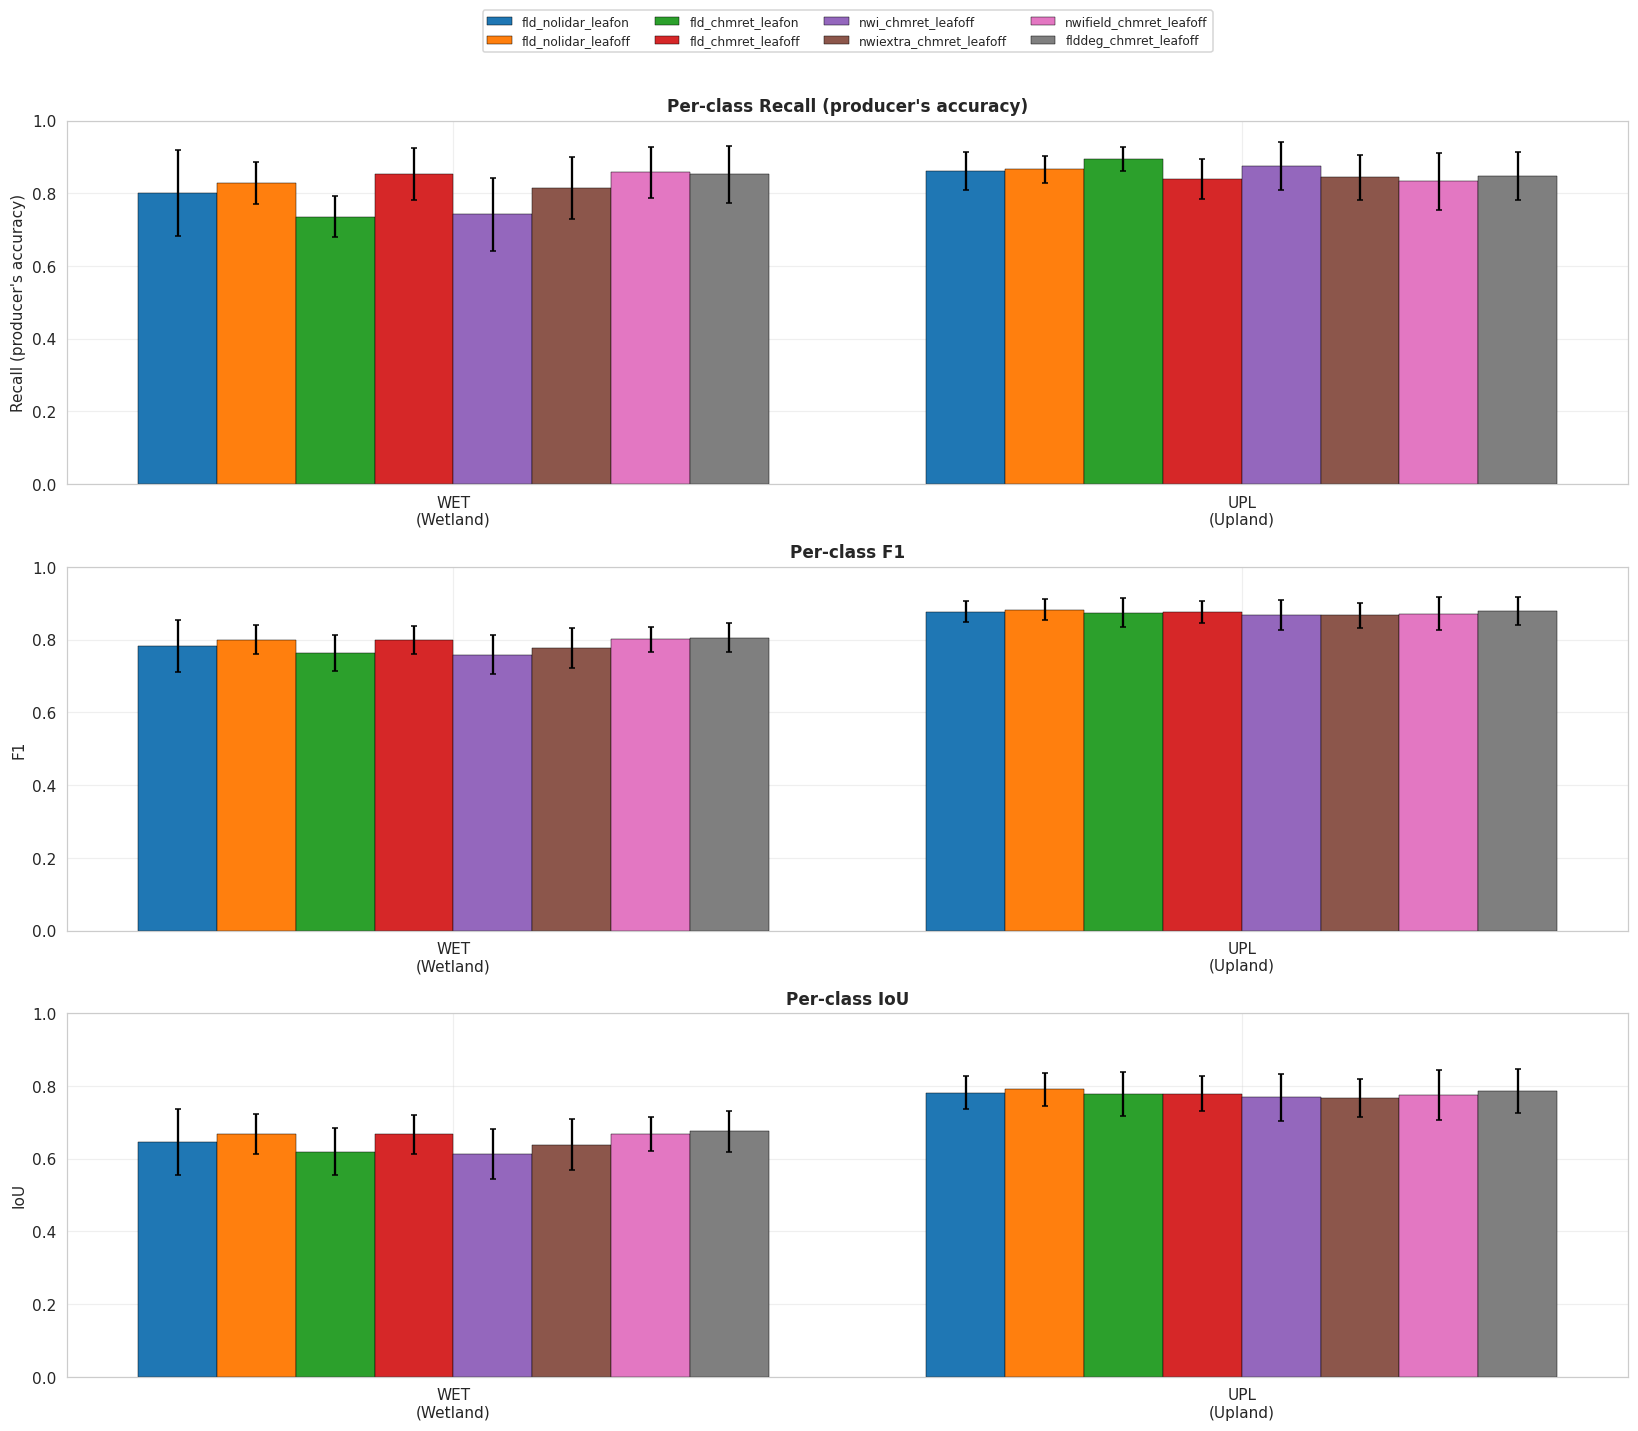

In [13]:
PER_CLASS_METRICS = [
    ("recall", "Recall (producer's accuracy)"),
    ("f1",     "F1"),
    ("iou",    "IoU"),
]

def per_class_table(metric):
    """(config x class) mean and sd over seeds for one per-class metric."""
    g = long.groupby(["config", "class"], observed=True)[metric]
    mean = g.mean().unstack("class").reindex(index=present_cfgs, columns=CLASS_ORDER)
    sd = g.std().unstack("class").reindex(index=present_cfgs, columns=CLASS_ORDER).fillna(0)
    return mean, sd

fig, axes = plt.subplots(3, 1, figsize=(15, 13))
x = np.arange(len(CLASS_ORDER))
w = 0.8 / max(len(present_cfgs), 1)
for ax, (metric, title) in zip(axes, PER_CLASS_METRICS):
    mean, sd = per_class_table(metric)
    for j, cfg in enumerate(present_cfgs):
        off = (j - (len(present_cfgs) - 1) / 2) * w
        ax.bar(x + off, mean.loc[cfg].values, w, yerr=sd.loc[cfg].values,
               capsize=2, label=cfg, color=CONFIG_COLORS[cfg],
               edgecolor="black", linewidth=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{c}\n({CLASS_FULL[c]})" for c in CLASS_ORDER])
    ax.set_ylabel(title); ax.set_title(f"Per-class {title}")
    ax.set_ylim(0, 1.0)
axes[0].legend(ncol=4, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, 1.32))
fig.tight_layout()
savefig(fig, "02_per_class_bars")
plt.show()


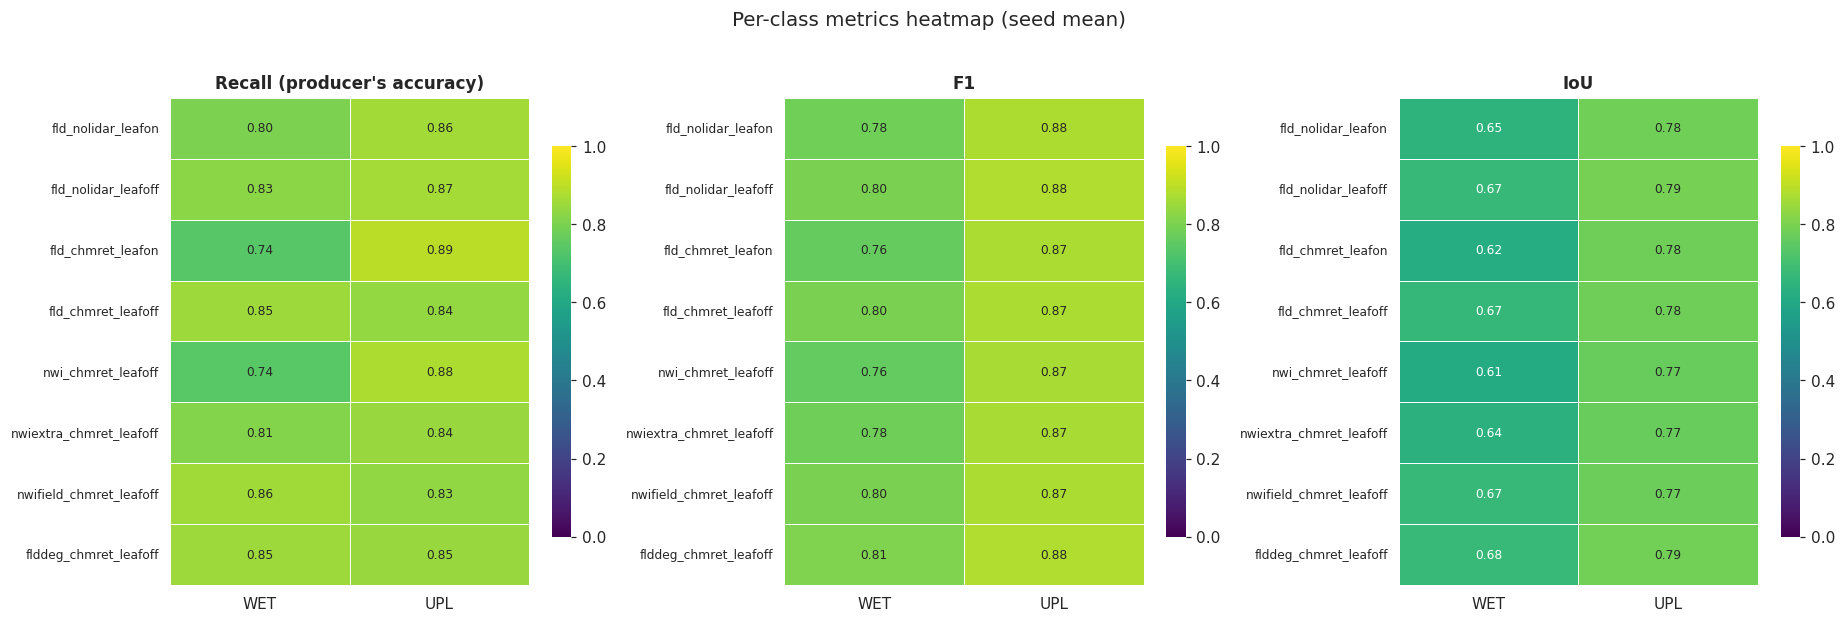

In [14]:
# Compact heatmaps: config (rows) x class (cols), one panel per metric.
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, (metric, title) in zip(axes, PER_CLASS_METRICS):
    mean, _ = per_class_table(metric)
    sns.heatmap(mean, ax=ax, cmap="viridis", vmin=0, vmax=1, annot=True, fmt=".2f",
                linewidths=0.5, linecolor="white", annot_kws={"fontsize": 8},
                cbar_kws={"shrink": 0.8})
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_yticklabels(present_cfgs, rotation=0, fontsize=8)
fig.suptitle("Per-class metrics heatmap (seed mean)", y=1.02, fontsize=13)
fig.tight_layout()
savefig(fig, "02_per_class_heatmap")
plt.show()


## 3 · Confusion matrices (seed-mean)

From `confusion_mean/<config>.csv` (true rows × predicted columns, averaged over
seeds). **Raw counts** show absolute pixel volumes (dominated by UPL); **row-
normalized %** shows where each true class's pixels actually land — the diagonal
is per-class recall, off-diagonals are the confusion structure (the FSW↔UPL
below-canopy story lives here).

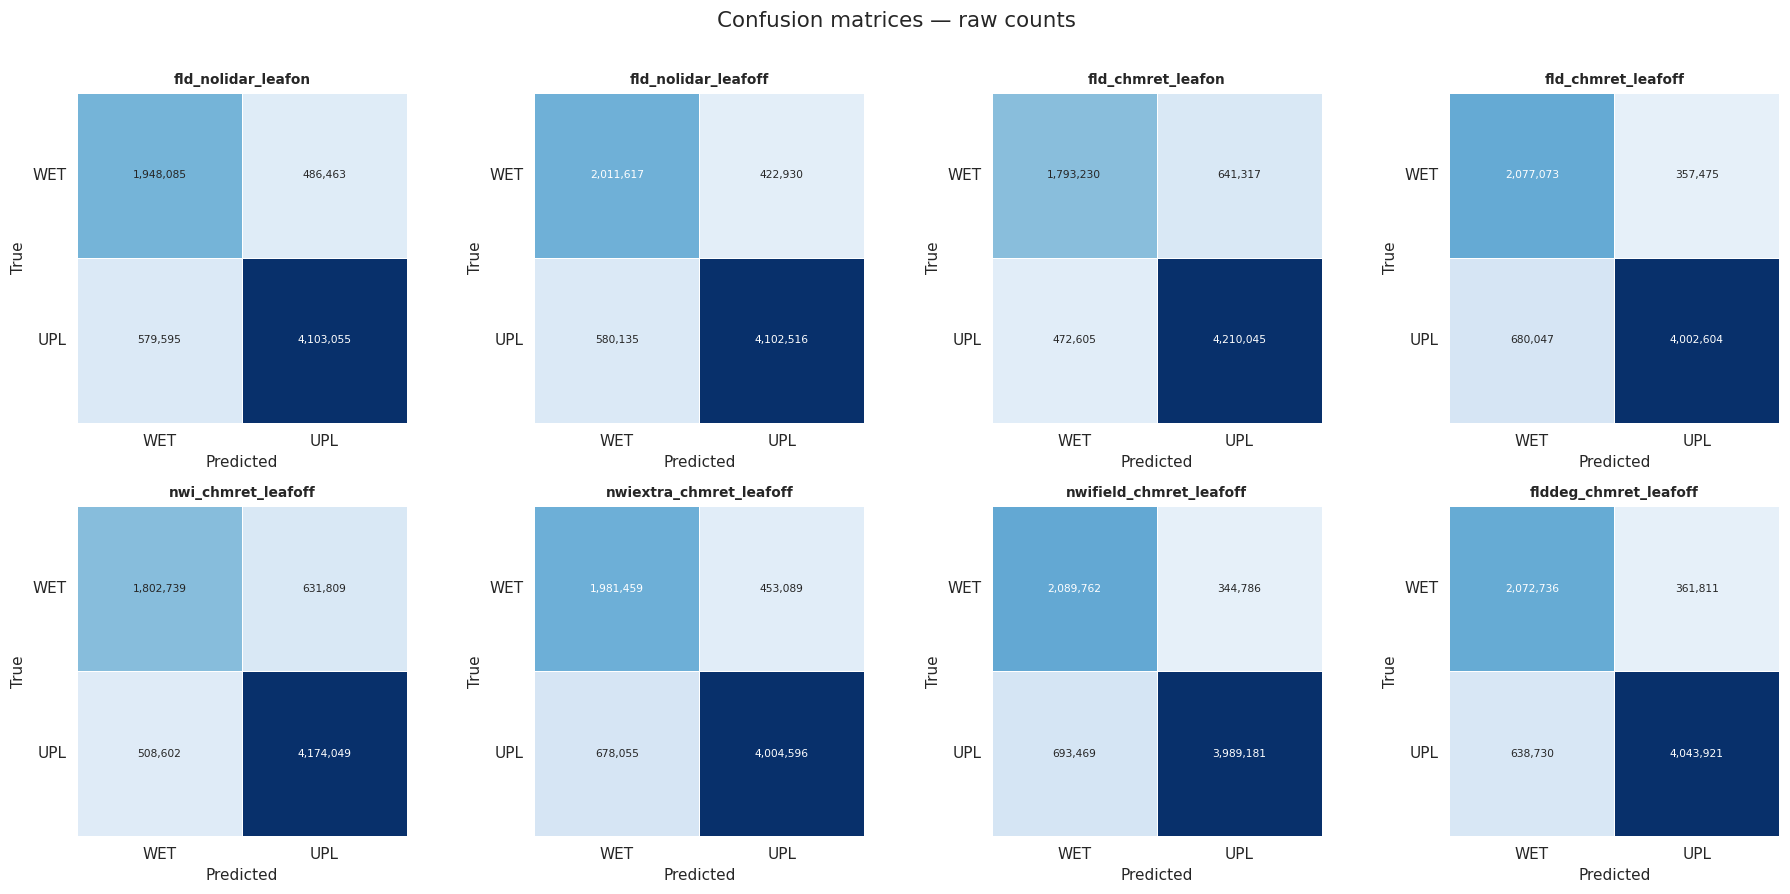

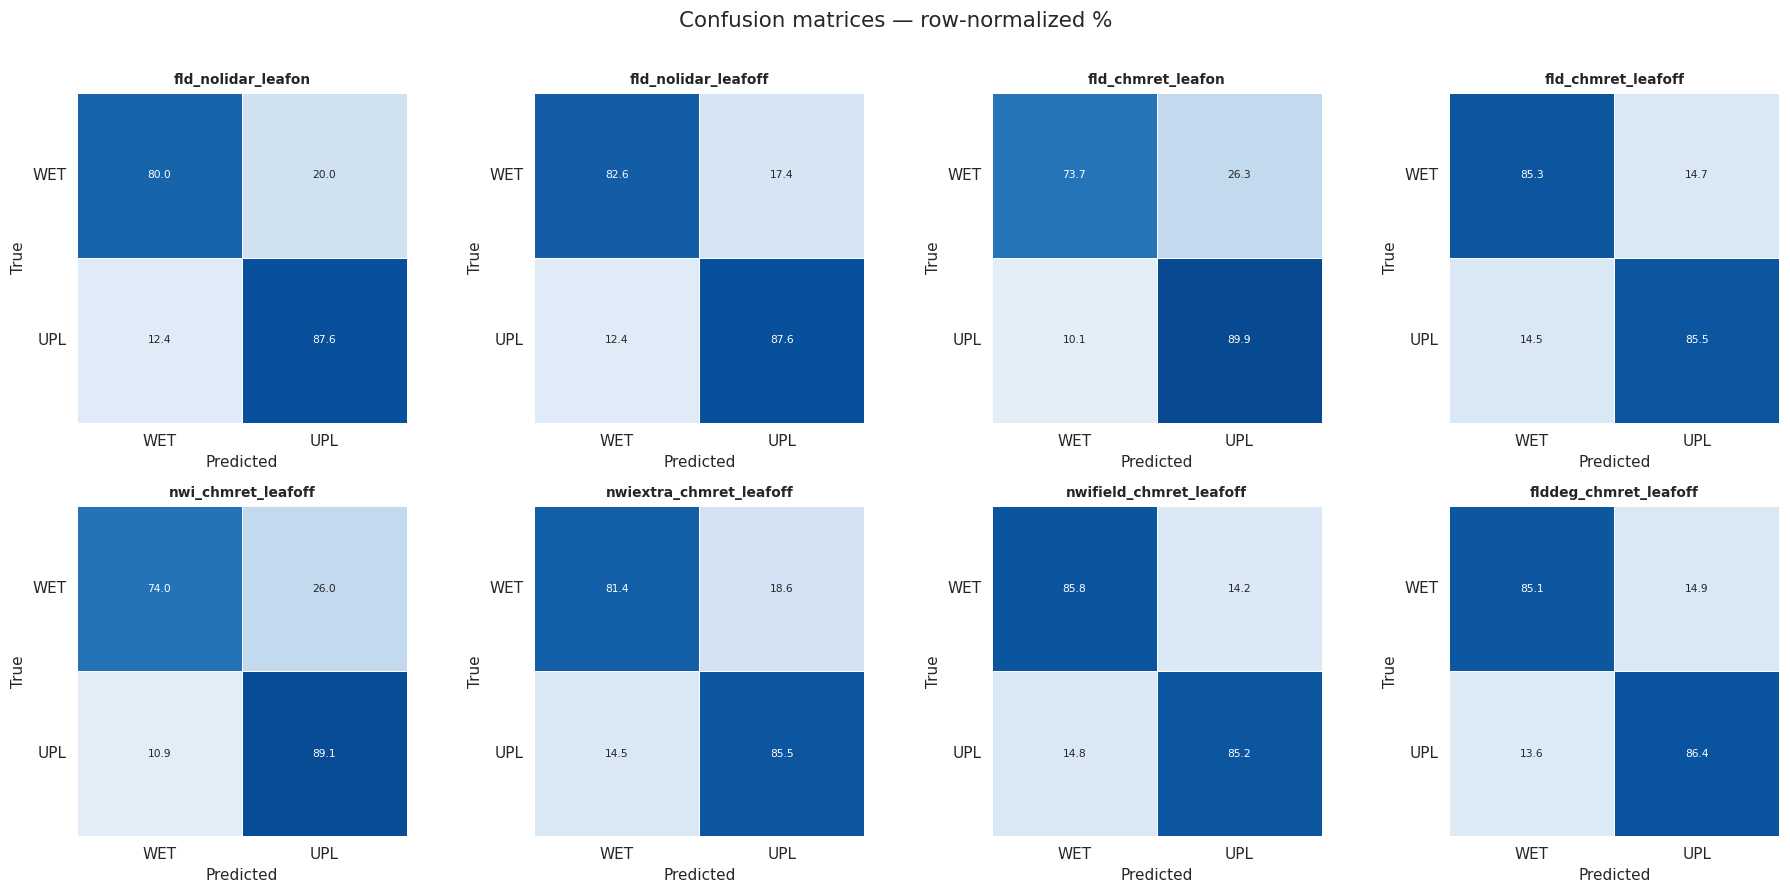

In [15]:
def load_confusion(cfg):
    f = ANALYSIS_DIR / "confusion_mean" / f"{cfg}.csv"
    if not f.exists():
        return None
    cm = pd.read_csv(f, index_col=0)
    return cm.reindex(index=CLASS_ORDER, columns=CLASS_ORDER)

def plot_cm(ax, cm, title, normalize=False):
    M = cm.astype(float)
    if normalize:
        M = M.div(M.sum(axis=1), axis=0) * 100.0
        fmt, vmax = ".1f", 100
    else:
        fmt, vmax = ",.0f", None
    sns.heatmap(M, ax=ax, cmap="Blues", vmin=0, vmax=vmax, annot=True, fmt=fmt,
                cbar=False, square=True, linewidths=0.5, linecolor="white",
                annot_kws={"fontsize": 7})
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title, fontsize=9)
    ax.set_yticklabels(CLASS_ORDER, rotation=0)

cfgs_with_cm = [c for c in present_cfgs if load_confusion(c) is not None]

for normalize, tag in [(False, "raw counts"), (True, "row-normalized %")]:
    n = len(cfgs_with_cm); ncol = 4; nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 4 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, cfg in zip(axes, cfgs_with_cm):
        plot_cm(ax, load_confusion(cfg), cfg, normalize=normalize)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(f"Confusion matrices — {tag}", y=1.01, fontsize=14)
    fig.tight_layout()
    savefig(fig, f"03_confusion_{'norm' if normalize else 'raw'}")
    plt.show()


## 4 · SHAP feature importance

Per-band GradientSHAP importance from `dl_09_shap_factorial.py`, **averaged across
seeds** for each config (`importance_overall`). Absolute SHAP magnitudes are not
comparable across models (different channel counts / scales), so for cross-model
comparison we also show each model's importance **normalized to its own total**
(fraction of attributed importance). SHAP exists only for the field-trained
configs by default.

In [16]:
def load_shap():
    """Return {config: {seed: {'overall': dict, 'per_class': {cls: dict}, 'bands': [...]}}}"""
    out = {}
    for cfg in CONFIG_ORDER:
        cfg_dir = RESULTS_DIR / cfg
        if not cfg_dir.is_dir():
            continue
        for seed_dir in sorted(cfg_dir.glob("seed*")):
            js = list(seed_dir.glob("shap/*_shap_importance.json"))
            if not js:
                continue
            d = json.loads(js[0].read_text())
            seed = int(seed_dir.name[4:])
            out.setdefault(cfg, {})[seed] = {
                "overall": d["importance_overall"],
                "per_class": d.get("importance_per_class", {}),
                "bands": d["predictor_names"],
            }
    return out

shap_raw = load_shap()
shap_cfgs = order_configs(shap_raw.keys())
print("SHAP available for:", shap_cfgs)

def shap_overall_mean(cfg):
    """Seed-mean overall importance as a Series indexed by band (cell's band set)."""
    seeds = shap_raw[cfg]
    bands = next(iter(seeds.values()))["bands"]
    mat = np.array([[s["overall"][b] for b in bands] for s in seeds.values()])
    return pd.Series(mat.mean(axis=0), index=bands), len(seeds)


SHAP available for: ['fld_nolidar_leafon', 'fld_nolidar_leafoff', 'fld_chmret_leafon', 'fld_chmret_leafoff', 'nwi_chmret_leafoff', 'nwiextra_chmret_leafoff', 'nwifield_chmret_leafoff', 'flddeg_chmret_leafoff']


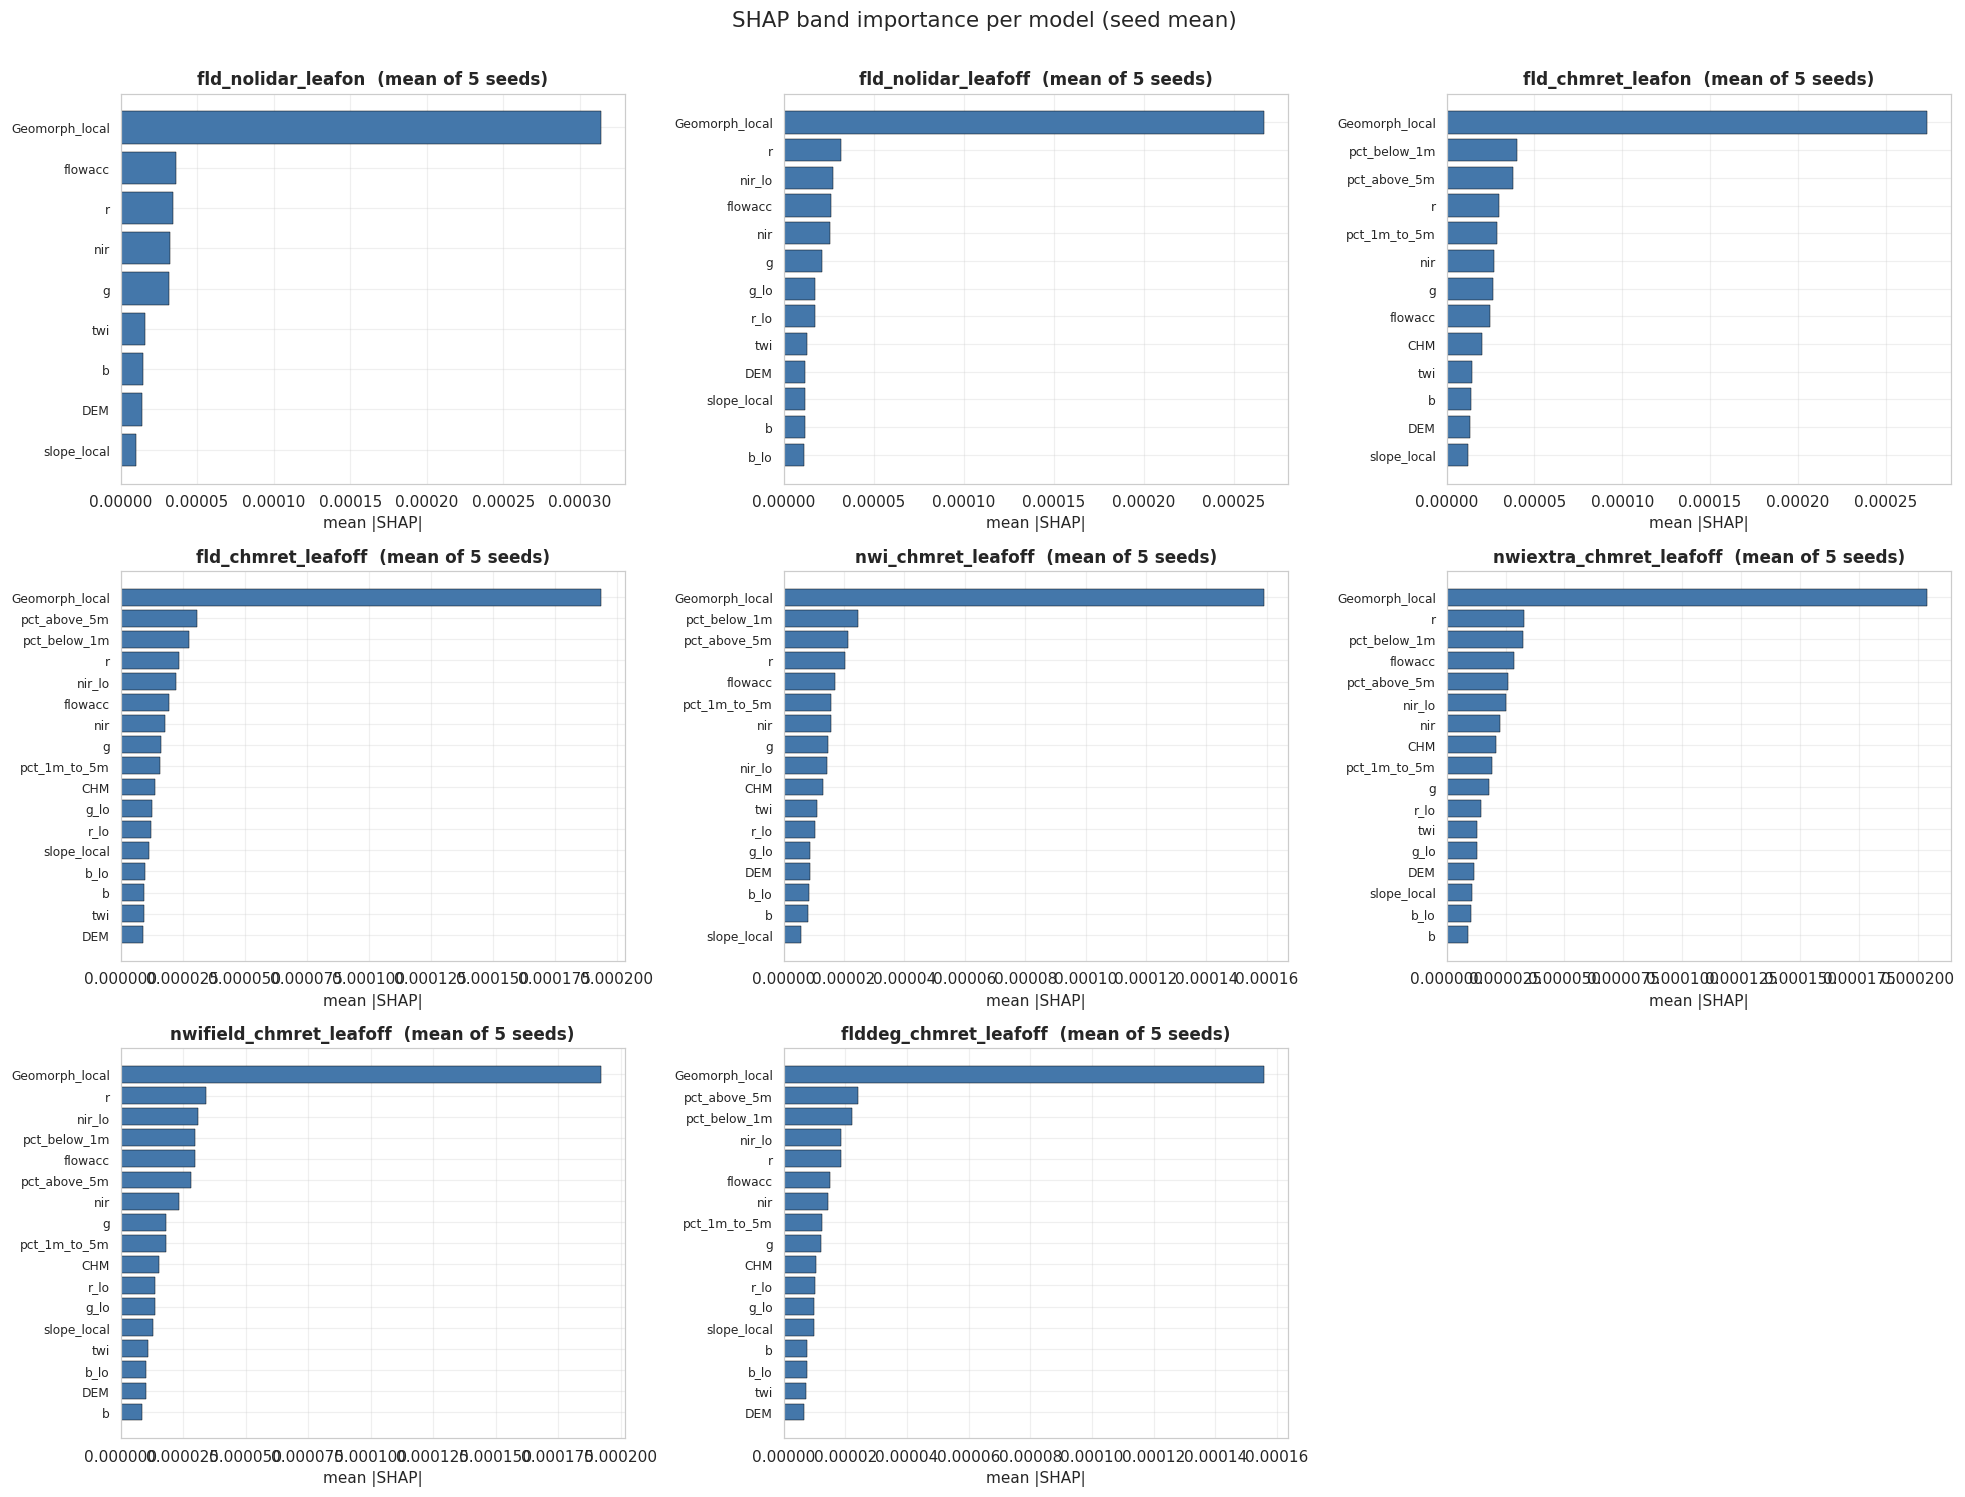

In [17]:
# Per-config SHAP bar charts (seed mean), sorted by importance.
n = len(shap_cfgs); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(6 * ncol, 4.5 * nrow))
axes = np.atleast_1d(axes).ravel()
for ax, cfg in zip(axes, shap_cfgs):
    s, k = shap_overall_mean(cfg)
    s = s.sort_values()
    ax.barh(range(len(s)), s.values, color="#4477aa", edgecolor="black", linewidth=0.3)
    ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index, fontsize=8)
    ax.set_title(f"{cfg}  (mean of {k} seeds)")
    ax.set_xlabel("mean |SHAP|")
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle("SHAP band importance per model (seed mean)", y=1.005, fontsize=14)
fig.tight_layout()
savefig(fig, "04_shap_per_model")
plt.show()


### 4a · One-hot aggregation check — sum vs per-channel mean

`run_shap` aggregates each band's channels by **summing** `|SHAP|`
(`dl_07_shap_analysis.py`). For the one-hot **`Geomorph_local`** band that is a sum
over **10** channels, while every continuous band is a single channel — so the sum
mechanically inflates Geomorphon's apparent importance relative to the
single-channel bands. The **per-channel mean** (`sum / n_channels`) is the
fair-per-channel view; a band's true standing sits **between** the two.

Because `n_channels` is exact and fixed (one-hot → `num_classes`, else 1), the mean
is recovered from the **already-saved JSONs without re-running SHAP**. Below: both
views side by side (one-hot bands flagged **red** are the only bars that move), plus
the per-config rank shift printed for each one-hot band. If Geomorphon stays near
the top under the mean, its importance is real; if it drops to mid-pack, the
headline rank was mostly the channel-count artifact.

Multi-channel (one-hot) bands: {'Geomorph_local': 10}
  fld_nolidar_leafon     Geomorph_local  rank  1/9 (sum)  ->   5/9 (per-channel mean)
  fld_nolidar_leafoff    Geomorph_local  rank  1/13 (sum)  ->   3/13 (per-channel mean)
  fld_chmret_leafon      Geomorph_local  rank  1/13 (sum)  ->   5/13 (per-channel mean)
  fld_chmret_leafoff     Geomorph_local  rank  1/17 (sum)  ->   6/17 (per-channel mean)
  nwi_chmret_leafoff     Geomorph_local  rank  1/17 (sum)  ->   5/17 (per-channel mean)
  nwiextra_chmret_leafoff Geomorph_local  rank  1/17 (sum)  ->   8/17 (per-channel mean)
  nwifield_chmret_leafoff Geomorph_local  rank  1/17 (sum)  ->   7/17 (per-channel mean)
  flddeg_chmret_leafoff  Geomorph_local  rank  1/17 (sum)  ->   5/17 (per-channel mean)


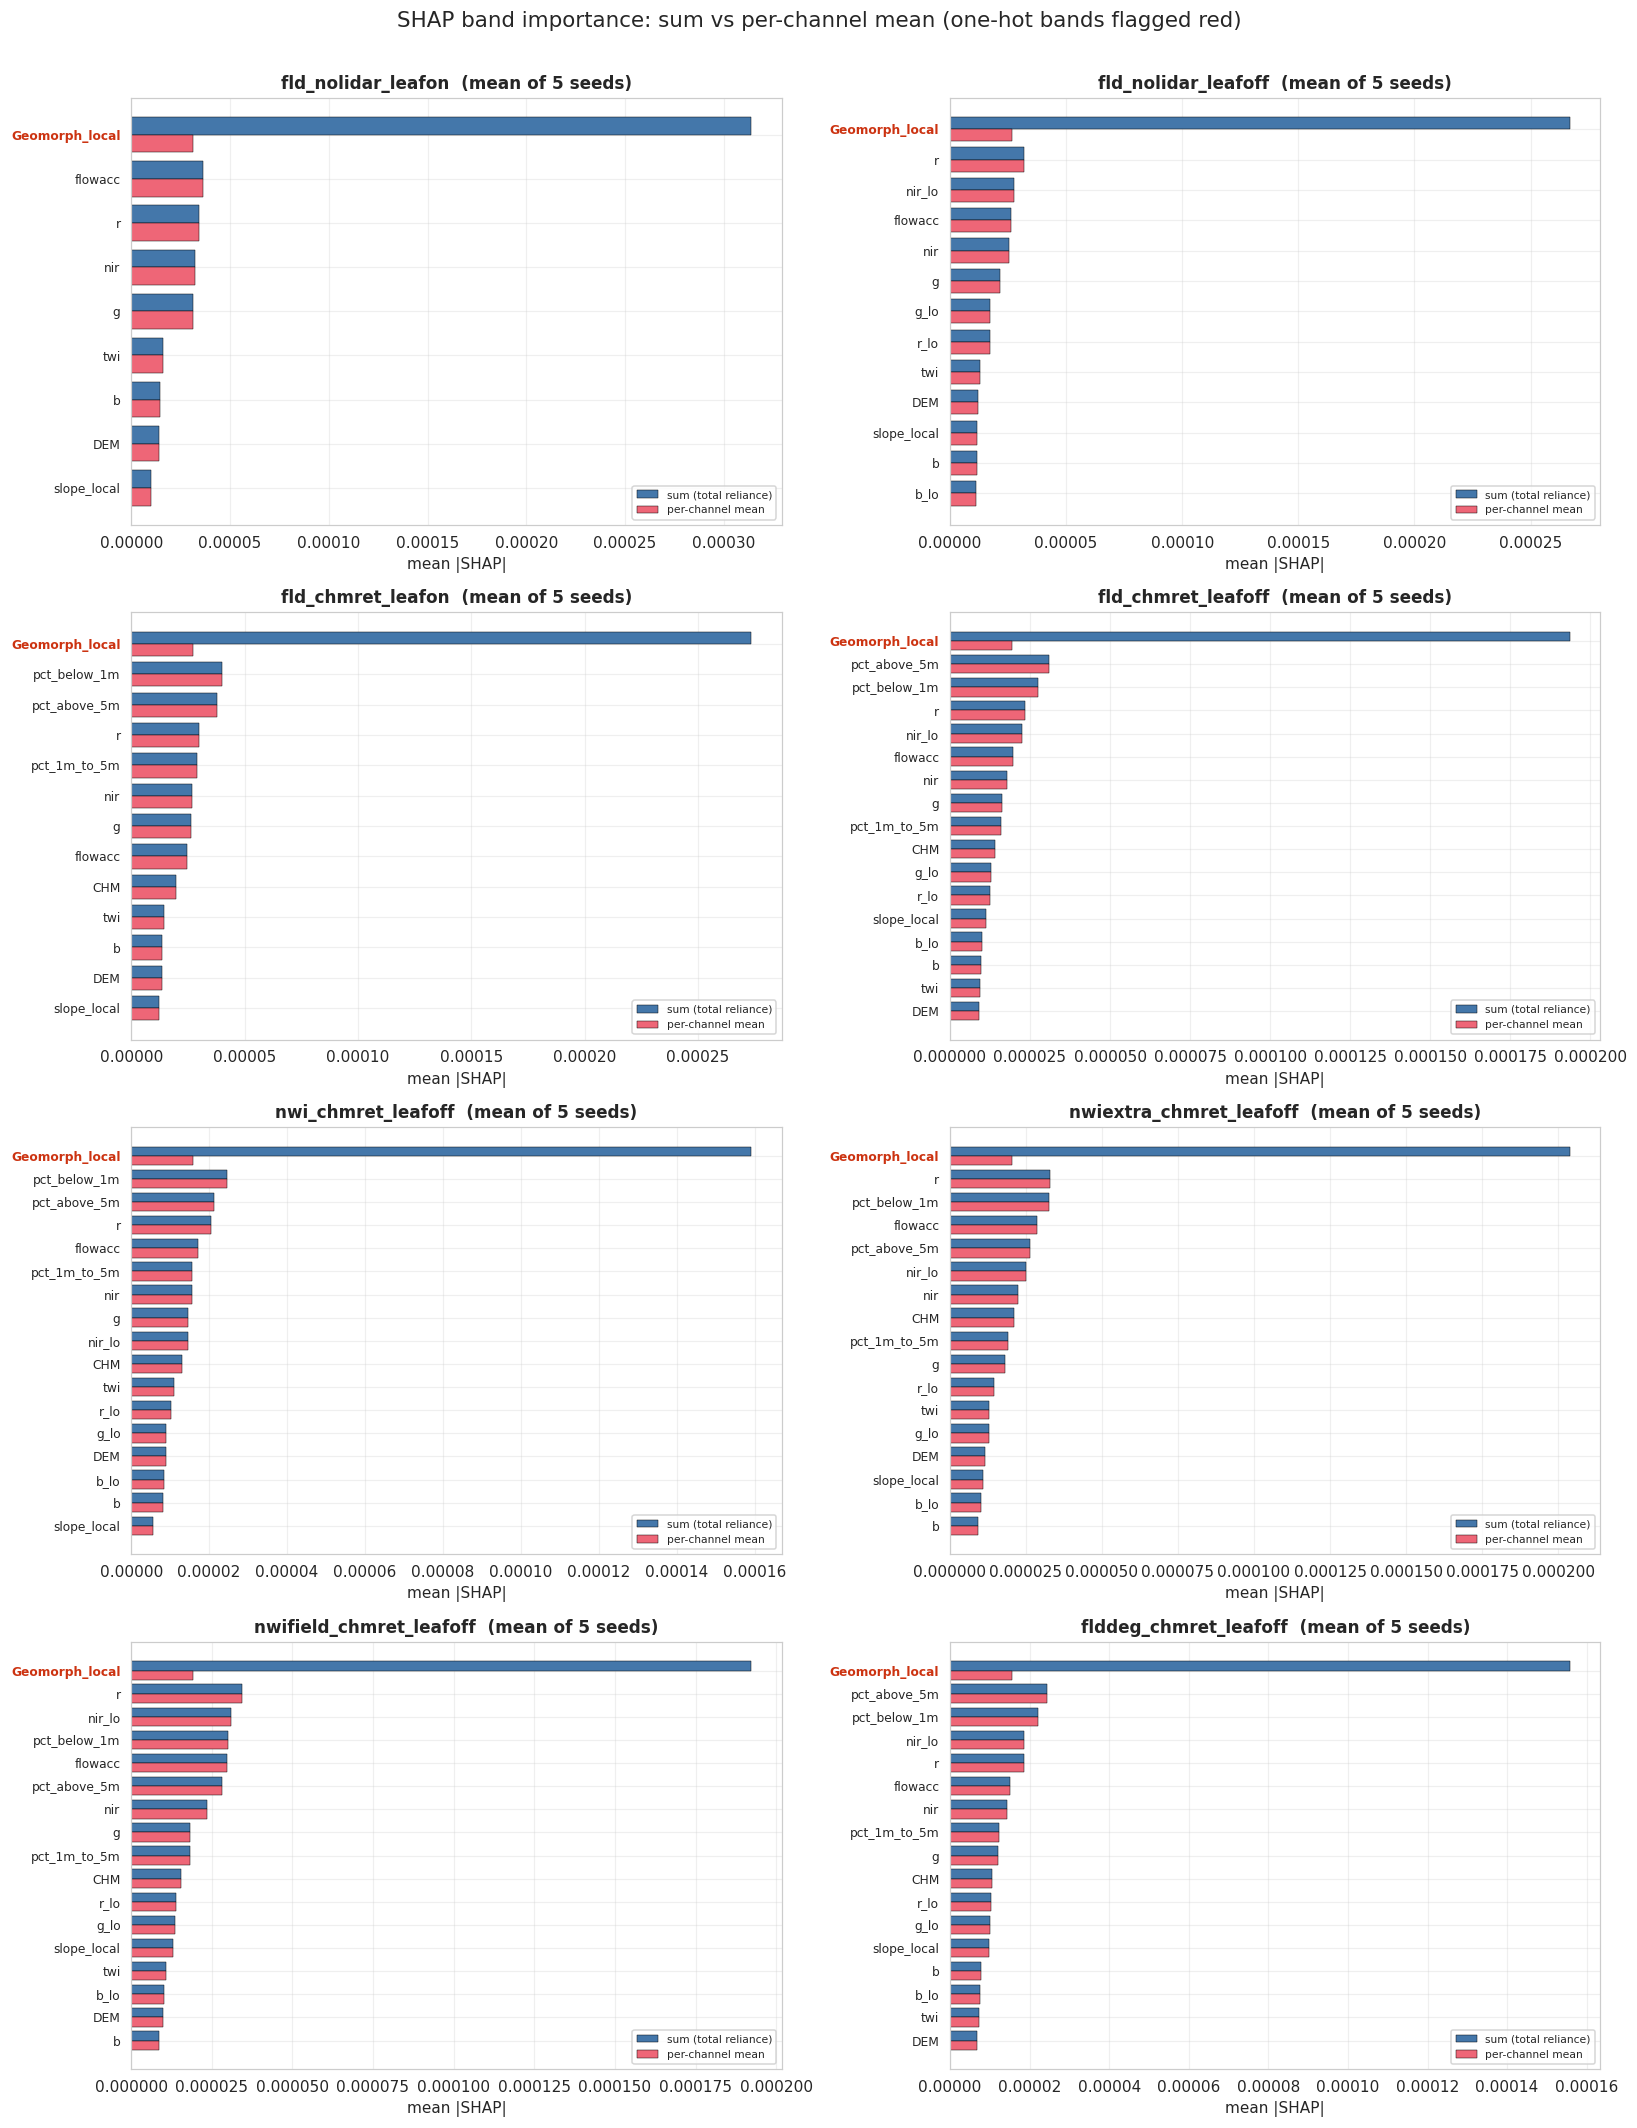

In [18]:
# --- Dual aggregation: SUM (total reliance) vs per-channel MEAN --------------
# run_shap aggregates each band's channels by SUMMING |SHAP| (dl_07_shap_analysis.py).
# For the one-hot Geomorph_local band that is a sum over 10 channels, while every
# continuous band is a single channel -- so the sum mechanically inflates the
# one-hot band vs the single-channel bands. The per-channel MEAN (= sum / n_channels)
# is the fair-per-channel view; the truth sits between the two. n_channels is exact
# and deterministic from the band-normalization config, so the mean is recovered
# from the already-saved JSONs WITHOUT re-running SHAP.

def _find_band_config():
    """Locate dl_band_config.json (the canonical normalization rules)."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        for rel in ("dl_band_config.json",
                    "Python_Code_Analysis/DL_Pipeline_v2/dl_band_config.json"):
            c = base / rel
            if c.is_file():
                return c
    c = Path("/ibstorage/anthony/NYS_Wetlands_DL/Python_Code_Analysis/"
             "DL_Pipeline_v2/dl_band_config.json")
    if c.is_file():
        return c
    raise FileNotFoundError("dl_band_config.json not found")

_BAND_NORM = json.loads(_find_band_config().read_text()).get("band_normalization", {})

def band_n_channels(band):
    """Expanded channel count for a band -- mirrors build_channel_mapping in
    dl_07_shap_analysis.py exactly (one_hot -> num_classes, everything else -> 1)."""
    cfg = _BAND_NORM.get(band, {})
    return int(cfg["num_classes"]) if cfg.get("method") == "one_hot" else 1

def shap_overall_dual(cfg):
    """(sum_series, mean_series, k_seeds): sum = saved per-band total |SHAP|;
    mean = per-channel (sum / n_channels). Identical except for one-hot bands."""
    s_sum, k = shap_overall_mean(cfg)
    nchan = pd.Series({b: band_n_channels(b) for b in s_sum.index})
    return s_sum, s_sum / nchan, k

# Report how far each multi-channel band's rank moves between the two views.
_multi = sorted({b for cfg in shap_cfgs for b in shap_overall_mean(cfg)[0].index
                 if band_n_channels(b) > 1})
print("Multi-channel (one-hot) bands:",
      {b: band_n_channels(b) for b in _multi} or "none -- all bands single-channel")
for cfg in shap_cfgs:
    s_sum, s_mean, _ = shap_overall_dual(cfg)
    r_sum = s_sum.rank(ascending=False).astype(int)
    r_mean = s_mean.rank(ascending=False).astype(int)
    for b in _multi:
        if b in s_sum.index:
            print(f"  {cfg:<22} {b:<15} rank {r_sum[b]:>2}/{len(s_sum)} (sum)"
                  f"  ->  {r_mean[b]:>2}/{len(s_mean)} (per-channel mean)")

# Dual horizontal bars per model: SUM vs per-channel MEAN, bands ordered by SUM.
# One-hot band labels are flagged red -- they are the only bars that move.
n = len(shap_cfgs); ncol = 2; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(7.5 * ncol, 4.8 * nrow))
axes = np.atleast_1d(axes).ravel()
for ax, cfg in zip(axes, shap_cfgs):
    s_sum, s_mean, k = shap_overall_dual(cfg)
    order = s_sum.sort_values().index
    y = np.arange(len(order)); h = 0.4
    ax.barh(y + h / 2, s_sum.reindex(order).values, height=h, color="#4477aa",
            edgecolor="black", linewidth=0.3, label="sum (total reliance)")
    ax.barh(y - h / 2, s_mean.reindex(order).values, height=h, color="#ee6677",
            edgecolor="black", linewidth=0.3, label="per-channel mean")
    ax.set_yticks(y); ax.set_yticklabels(order, fontsize=8)
    for tick, b in zip(ax.get_yticklabels(), order):
        if band_n_channels(b) > 1:
            tick.set_color("#cc3311"); tick.set_fontweight("bold")
    ax.set_title(f"{cfg}  (mean of {k} seeds)")
    ax.set_xlabel("mean |SHAP|")
    ax.legend(fontsize=7, loc="lower right")
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle("SHAP band importance: sum vs per-channel mean (one-hot bands flagged red)",
             y=1.005, fontsize=14)
fig.tight_layout()
savefig(fig, "04_shap_dual_sum_mean")
plt.show()


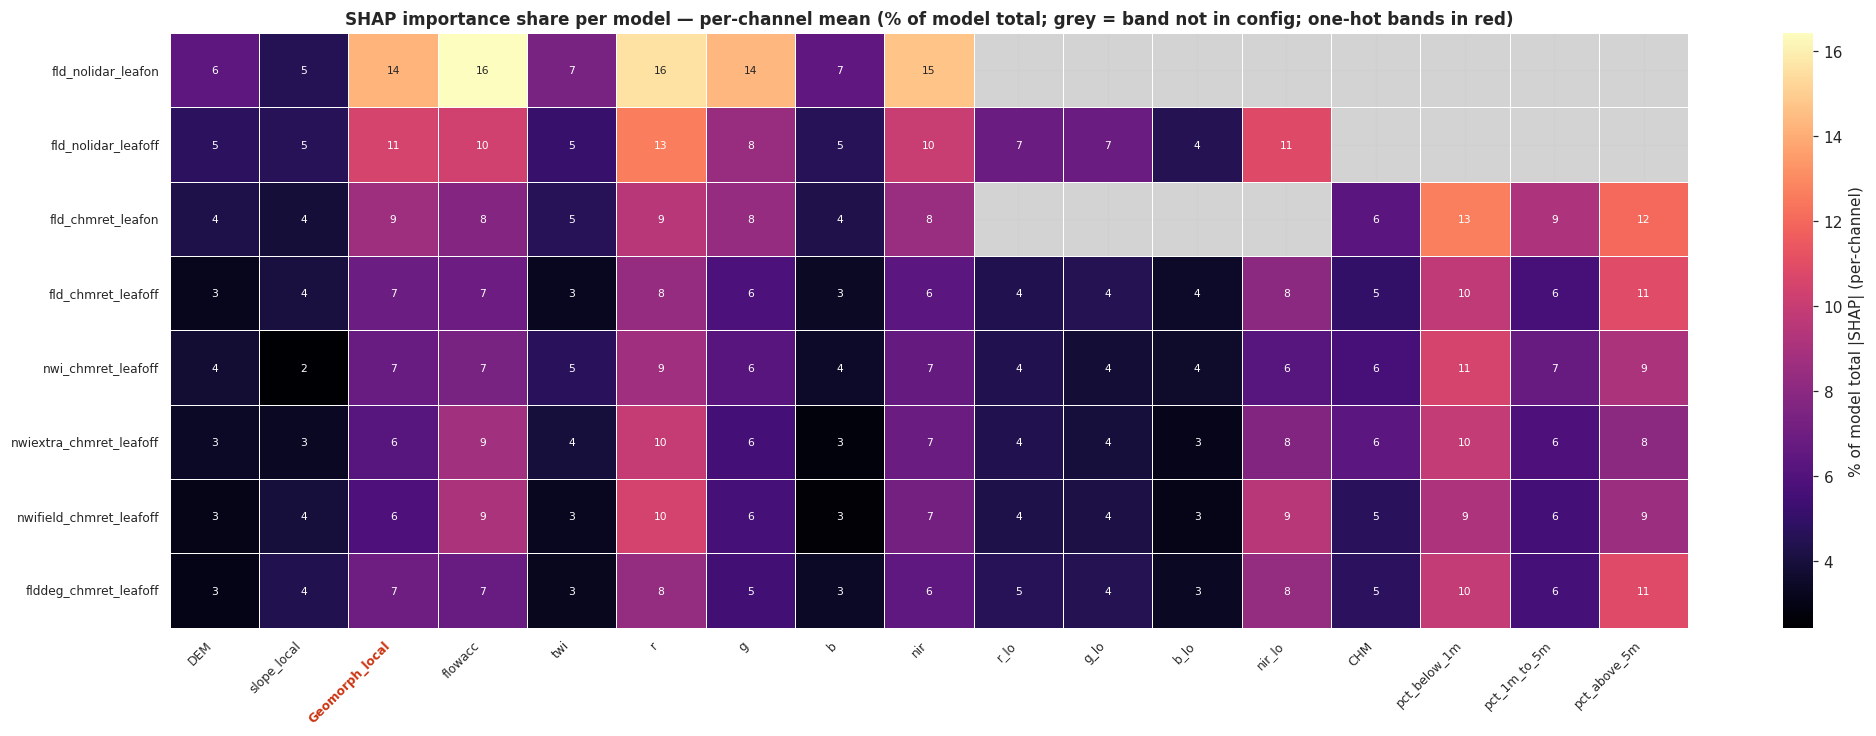

In [19]:
# Cross-model comparison: each model normalized to its own total importance,
# so bands are comparable across configs. Bands a config doesn't use are blank.
# Uses the PER-CHANNEL MEAN aggregation (not the raw sum) so the one-hot
# Geomorph_local band is not inflated 10x relative to single-channel bands.
all_bands = []
for cfg in shap_cfgs:
    for b in shap_overall_mean(cfg)[0].index:
        if b not in all_bands:
            all_bands.append(b)

norm = pd.DataFrame(index=shap_cfgs, columns=all_bands, dtype=float)
for cfg in shap_cfgs:
    _, s, _ = shap_overall_dual(cfg)          # per-channel mean
    norm.loc[cfg, s.index] = (s / s.sum()).values

fig, ax = plt.subplots(figsize=(1.0 * len(all_bands) + 2, 0.6 * len(shap_cfgs) + 2))
ax.set_facecolor("lightgray")        # shows through where a band is masked out
sns.heatmap(norm.astype(float) * 100, ax=ax, cmap="magma", mask=norm.isna(),
            annot=True, fmt=".0f", linewidths=0.5, linecolor="white",
            annot_kws={"fontsize": 7}, cbar_kws={"label": "% of model total |SHAP| (per-channel)"})
ax.set_yticklabels(shap_cfgs, rotation=0, fontsize=8)
# Flag one-hot bands on the x-axis (their share is per-channel, not summed).
ax.set_xticklabels(all_bands, rotation=45, ha="right", fontsize=8)
for tick, b in zip(ax.get_xticklabels(), all_bands):
    if band_n_channels(b) > 1:
        tick.set_color("#cc3311"); tick.set_fontweight("bold")
ax.set_title("SHAP importance share per model — per-channel mean "
             "(% of model total; grey = band not in config; one-hot bands in red)")
fig.tight_layout()
savefig(fig, "04_shap_share_heatmap")
plt.show()


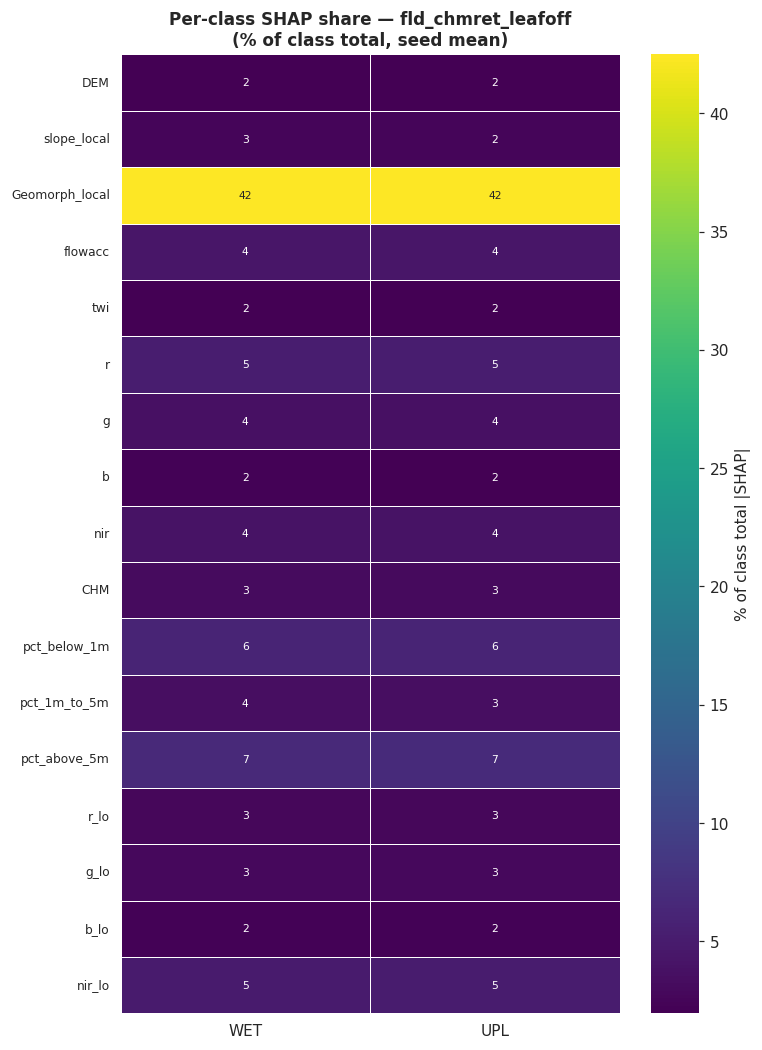

In [20]:
# Per-class SHAP for one config: band (rows) x class (cols), seed mean.
# Change FOCUS_CFG to inspect a different model.
FOCUS_CFG = "fld_chmret_leafoff" if "fld_chmret_leafoff" in shap_cfgs else shap_cfgs[0]

def shap_per_class_mean(cfg):
    seeds = shap_raw[cfg]
    bands = next(iter(seeds.values()))["bands"]
    classes = list(next(iter(seeds.values()))["per_class"].keys()) or CLASS_ORDER
    cube = np.array([[[s["per_class"][cls][b] for cls in classes] for b in bands]
                     for s in seeds.values()])          # (seed, band, class)
    return pd.DataFrame(cube.mean(axis=0), index=bands, columns=classes)

pc = shap_per_class_mean(FOCUS_CFG)
pc_norm = pc / pc.sum(axis=0)        # share within each class

fig, ax = plt.subplots(figsize=(7, 0.45 * len(pc) + 2))
sns.heatmap(pc_norm * 100, ax=ax, cmap="viridis", annot=True, fmt=".0f",
            linewidths=0.5, linecolor="white", annot_kws={"fontsize": 7},
            cbar_kws={"label": "% of class total |SHAP|"})
ax.set_yticklabels(pc.index, rotation=0, fontsize=8)
ax.set_xlabel(""); ax.set_ylabel("")
ax.set_title(f"Per-class SHAP share — {FOCUS_CFG}\n(% of class total, seed mean)")
fig.tight_layout()
savefig(fig, "04_shap_per_class")
plt.show()


### 4b · Within-Geomorphon breakdown — *which* form drives the band

§4a tells us *how much* of Geomorphon's rank is channel-count inflation; this tells
us *whether the remaining signal is real*. Using the per-channel array
(`{stem}_shap_per_channel.npz`, written by the updated `run_shap`), we split the
one-hot `Geomorph_local` band back into its 10 geomorphon forms and rank them.

- **Concentrated** in a few forms (e.g. `valley` / `depression` / `footslope` — the
  wet landform positions) → the band carries genuine landform signal the model
  exploits.
- **Smeared** evenly across all 10 forms (top-3 share ≈ 30%) → the high *summed*
  rank was mostly the 10-channel artifact, not real reliance on landform.

Each form is a one-hot channel, so GradientSHAP attributes to both its *presence*
and *absence* — a high value means the model keys on that form being on **or** off.
**Requires a post-update `dl_09 --force` re-run** to produce the `.npz` files; the
cell prints a hint and no-ops until they exist.

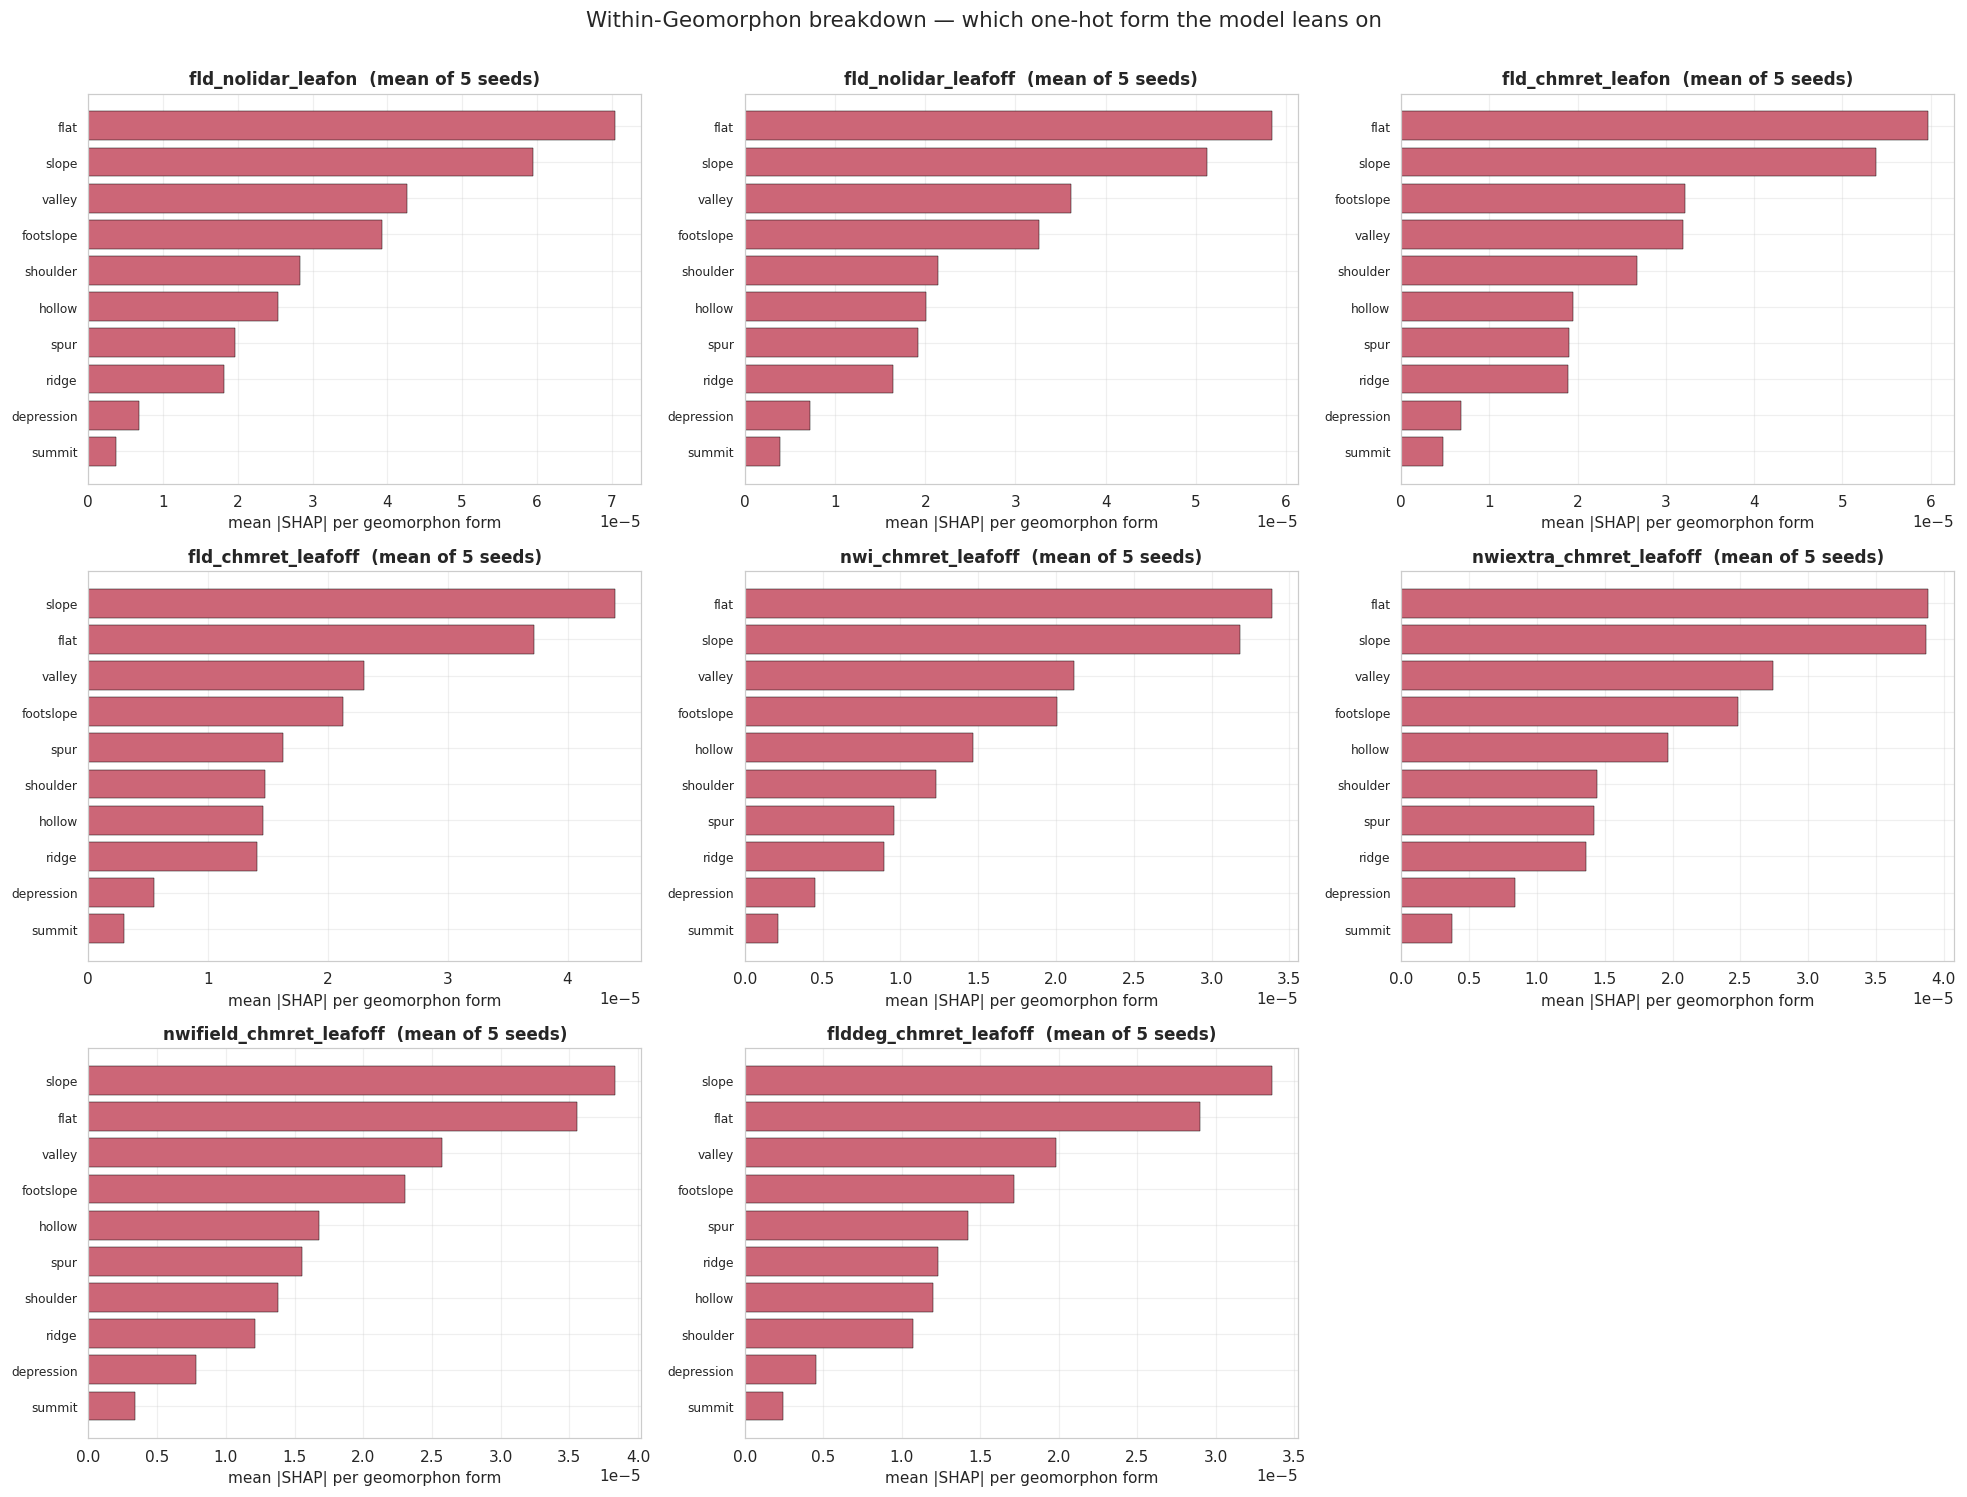

Geomorphon concentration (share of the band's |SHAP|):
  fld_nolidar_leafon     lead = flat        top1=22.5%  top3=55.0%
  fld_nolidar_leafoff    lead = flat        top1=21.9%  top3=54.6%
  fld_chmret_leafon      lead = flat        top1=21.9%  top3=53.3%
  fld_chmret_leafoff     lead = slope       top1=22.7%  top3=53.8%
  nwi_chmret_leafoff     lead = flat        top1=21.3%  top3=54.6%
  nwiextra_chmret_leafoff lead = flat        top1=19.1%  top3=51.5%
  nwifield_chmret_leafoff lead = slope       top1=19.9%  top3=51.8%
  flddeg_chmret_leafoff  lead = slope       top1=21.6%  top3=52.9%


In [21]:
# --- Within-Geomorphon breakdown (needs the per-channel .npz) ----------------
# run_shap (post-update) writes {stem}_shap_per_channel.npz next to the JSON:
#   shap_abs (n_classes, n_test, C_input), channel_band (parent band per channel).
# Splitting the one-hot Geomorph_local band back into its 10 geomorphon forms
# shows WHICH form the model leans on -- the diagnostic that tells "real signal
# concentrated in a few forms" apart from "smeared across all 10" (the summation
# artifact). Only present after a `dl_09 ... --force` re-run; no-ops gracefully
# (prints a hint) until the .npz files exist.

GEOMORPH_FORMS = {            # r.geomorphon class_range [1,10] -> standard form name
    1: "flat", 2: "summit", 3: "ridge", 4: "shoulder", 5: "spur",
    6: "slope", 7: "hollow", 8: "footslope", 9: "valley", 10: "depression",
}
ONEHOT_BAND = "Geomorph_local"

def load_geomorph_breakdown(cfg):
    """Seed-mean per-form mean|SHAP| for the one-hot band, or None if no .npz."""
    per_seed = []
    for seed_dir in sorted((RESULTS_DIR / cfg).glob("seed*")):
        npzs = list(seed_dir.glob("shap/*_shap_per_channel.npz"))
        if not npzs:
            continue
        z = np.load(npzs[0])
        idx = np.where(z["channel_band"].astype(str) == ONEHOT_BAND)[0]
        if idx.size == 0:
            continue
        # shap_abs: (n_classes, n_test, C) -> mean over classes & test -> (n_forms,)
        per_seed.append(z["shap_abs"][:, :, idx].mean(axis=(0, 1)))
    if not per_seed:
        return None
    m = np.mean(per_seed, axis=0)
    forms = [GEOMORPH_FORMS.get(i + 1, f"form{i + 1}") for i in range(len(m))]
    return pd.Series(m, index=forms), len(per_seed)

_geo = {cfg: load_geomorph_breakdown(cfg) for cfg in shap_cfgs}
_geo = {c: v for c, v in _geo.items() if v is not None}

if not _geo:
    print("No *_shap_per_channel.npz found yet. Re-run dl_09_shap_factorial.py with "
          "--force (post-update run_shap) to generate them, then re-run this cell.")
else:
    n = len(_geo); ncol = 3; nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(6 * ncol, 4.5 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, (cfg, (s, k)) in zip(axes, _geo.items()):
        s = s.sort_values()
        ax.barh(range(len(s)), s.values, color="#cc6677", edgecolor="black", linewidth=0.3)
        ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index, fontsize=8)
        ax.set_title(f"{cfg}  (mean of {k} seeds)")
        ax.set_xlabel("mean |SHAP| per geomorphon form")
    for ax in axes[len(_geo):]:
        ax.axis("off")
    fig.suptitle("Within-Geomorphon breakdown — which one-hot form the model leans on",
                 y=1.005, fontsize=14)
    fig.tight_layout()
    savefig(fig, "04b_geomorph_form_breakdown")
    plt.show()

    # Concentration check: is the band's signal in a few forms (real) or smeared
    # across all 10 (the artifact)? An even smear over 10 forms => top3 ~30%.
    print("Geomorphon concentration (share of the band's |SHAP|):")
    for cfg, (s, k) in _geo.items():
        tot = s.sum()
        top1 = s.max() / tot * 100
        top3 = s.sort_values(ascending=False).head(3).sum() / tot * 100
        print(f"  {cfg:<22} lead = {s.idxmax():<11} top1={top1:4.1f}%  top3={top3:4.1f}%")


## 5 · Extra views worth having

### 5a · Contrasts forest plot — *the actual experiment result*

`contrasts.csv` holds the paired-by-seed effects the factorial was designed to
estimate: each LiDAR tier's gain, the leaf-off main effect, the LiDAR×leaf-off
interaction, and the label gradient (NWI vs field vs degraded). A forest plot
(Δ ± sd, paired over seeds) reads these directly — points right of the dashed
zero line are improvements. This is more informative than the absolute bars
because it nets out per-seed split luck.

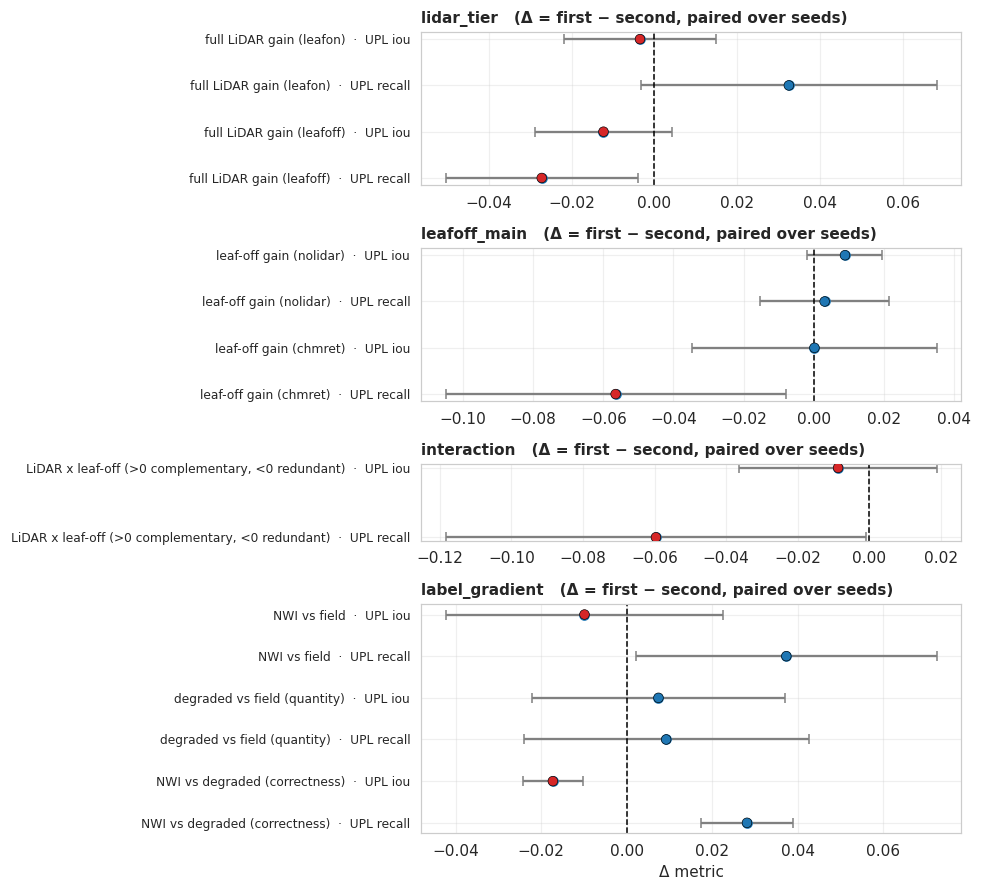

In [22]:
cdf = contrasts.copy()
# One readable row label per contrast x class x metric.
cdf["row"] = cdf["note"].fillna(cdf["contrast"]) + "  ·  " + cdf["class"] + " " + cdf["metric"]

groups = ["lidar_tier", "leafoff_main", "interaction", "label_gradient"]
present_groups = [g for g in groups if g in set(cdf["group"])]
fig, axes = plt.subplots(len(present_groups), 1,
                         figsize=(9, 1 + 0.45 * len(cdf)),
                         gridspec_kw={"height_ratios":
                             [max((cdf["group"] == g).sum(), 1) for g in present_groups]})
axes = np.atleast_1d(axes)
for ax, g in zip(axes, present_groups):
    sub = cdf[cdf["group"] == g].reset_index(drop=True)
    y = np.arange(len(sub))
    colors = ["#1f77b4" if m >= 0 else "#d62728" for m in sub["delta_mean"]]
    ax.errorbar(sub["delta_mean"], y, xerr=sub["delta_sd"].fillna(0),
                fmt="o", capsize=3, ecolor="gray", linestyle="none")
    ax.scatter(sub["delta_mean"], y, c=colors, zorder=3, s=40, edgecolor="black", linewidth=0.4)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_yticks(y); ax.set_yticklabels(sub["row"], fontsize=8)
    ax.set_title(f"{g}   (Δ = first − second, paired over seeds)", fontsize=10, loc="left")
    ax.invert_yaxis()
axes[-1].set_xlabel("Δ metric")
fig.tight_layout()
savefig(fig, "05a_contrasts_forest")
plt.show()


### 5b · Seed variability

How much does the seed (the train/val/test split + init) move each headline
number? Tight clusters mean the contrasts above are trustworthy; wide spreads
mean a difference may be split luck.

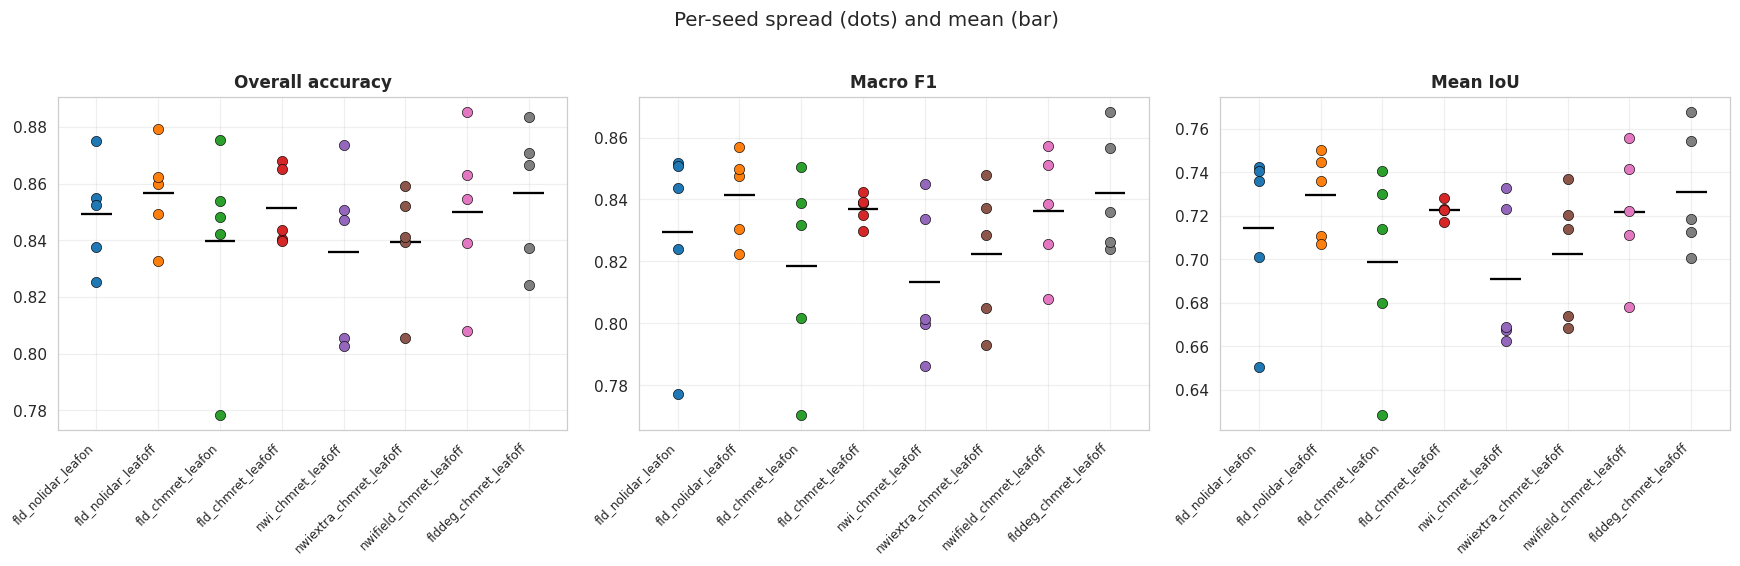

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (col, title) in zip(axes, OVERALL_METRICS):
    for i, cfg in enumerate(present_cfgs):
        vals = cell.loc[cell["config"] == cfg, col].values
        ax.scatter(np.full_like(vals, i, dtype=float), vals,
                   color=CONFIG_COLORS[cfg], s=45, edgecolor="black", linewidth=0.4, zorder=3)
        ax.hlines(vals.mean(), i - 0.25, i + 0.25, color="black", linewidth=1.5)
    ax.set_xticks(range(len(present_cfgs)))
    ax.set_xticklabels(present_cfgs, rotation=45, ha="right", fontsize=8)
    ax.set_title(title)
fig.suptitle("Per-seed spread (dots) and mean (bar)", y=1.02, fontsize=13)
fig.tight_layout()
savefig(fig, "05b_seed_variability")
plt.show()


### 5c · Reliance vs ablation — does SHAP agree with the experiment?

The factorial's design intent (plan §8.5) is to pair feature **reliance** (SHAP
importance — how much the model *leans* on a band) against feature **ablation**
(the contrast Δ — how much *adding* that feature actually *moved* the metric). A
band can be heavily relied on yet add little when removed (redundant), or be a
modest reliance yet a real marginal gain (complementary). Here we line up the
LiDAR/leaf-off bands' SHAP share in the full model against their ablation gains
from `contrasts.csv`.

In [24]:
# Marginal gains (from contrasts) for the feature additions, FSW IoU as the lead metric.
abl = contrasts[(contrasts["group"].isin(["lidar_tier", "leafoff_main"])) &
                (contrasts["class"] == "FSW") & (contrasts["metric"] == "iou")].copy()

if not abl.empty and shap_cfgs:
    # SHAP reliance: share of the bands that each addition introduces, in the
    # full field model (chmret_leafoff) — the most-loaded reference cell.
    ref = "fld_chmret_leafoff"
    if ref in shap_cfgs:
        share, _ = shap_overall_mean(ref)
        share = share / share.sum()
        ADD_BANDS = {
            "chm gain": ["CHM"],
            "returns gain": ["pct_below_1m", "pct_1m_to_5m", "pct_above_5m"],
            "full LiDAR gain": ["CHM", "pct_below_1m", "pct_1m_to_5m", "pct_above_5m"],
            "leaf-off gain": ["r_lo", "g_lo", "b_lo", "nir_lo"],
        }
        rows = []
        for _, r in abl.iterrows():
            for key, bands in ADD_BANDS.items():
                if key in str(r["note"]):
                    rel = share.reindex(bands).dropna().sum()
                    rows.append({"note": r["note"], "ablation_gain": r["delta_mean"],
                                 "ablation_sd": r["delta_sd"], "shap_share": rel})
                    break
        rel_df = pd.DataFrame(rows).drop_duplicates("note")

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.errorbar(rel_df["shap_share"], rel_df["ablation_gain"],
                    yerr=rel_df["ablation_sd"].fillna(0), fmt="o", capsize=3,
                    ecolor="gray", linestyle="none", zorder=2)
        ax.scatter(rel_df["shap_share"], rel_df["ablation_gain"], s=70,
                   c="#cc6677", edgecolor="black", zorder=3)
        for _, r in rel_df.iterrows():
            ax.annotate(r["note"], (r["shap_share"], r["ablation_gain"]),
                        fontsize=8, xytext=(5, 5), textcoords="offset points")
        ax.axhline(0, color="black", linestyle="--", linewidth=1)
        ax.set_xlabel("SHAP reliance — share of total |SHAP| in fld_chmret_leafoff")
        ax.set_ylabel("Ablation gain — Δ FSW IoU when feature added (paired)")
        ax.set_title("Reliance vs ablation for the below-canopy features")
        fig.tight_layout()
        savefig(fig, "05c_reliance_vs_ablation")
        plt.show()
    else:
        print("Reference config fld_chmret_leafoff has no SHAP yet — skipping 5c.")
else:
    print("Not enough SHAP/contrast data for the reliance-vs-ablation plot yet.")


Not enough SHAP/contrast data for the reliance-vs-ablation plot yet.


---
All figures are also written to `Models/factorial_results/analysis/figures/` for
dropping into the write-up. Re-run top-to-bottom after each `run_aggregate.sh` /
`dl_09_shap_factorial.py` pass — it picks up new cells automatically.

## 6 · Patch-count learning curve

How much does accuracy improve as the labeled training pool grows? Each level
(`n100 … n500`, then `full`) trains the best field config at a capped #patches,
3 seeds per level. The x-axis is the **realized** #train patches
(`training_log.json → data_split.train`), not the requested cap, so the curve
stays honest as the dataset grows (plan §9, `run_patchcurve.sh`).

In [25]:
# --- Follow-on study locations (siblings of factorial_results under Models/) ---
# MODELS_DIR + with_mode() come from the Setup cell; with_mode() appends the
# resolved <mode> level so v2's results_patchcurve_v2/<mode>/... resolves while
# v1 (no mode level) is untouched.
PATCHCURVE_DIR = with_mode(MODELS_DIR / f"results_patchcurve{_SUFFIX}")
ARCH_DIR       = with_mode(MODELS_DIR / f"results_arch{_SUFFIX}")
PRED_DIR       = MODELS_DIR.parent / "Data" / f"HUC_DL_Predictions{_SUFFIX}"
for p in (PATCHCURVE_DIR, ARCH_DIR, PRED_DIR):
    print(("ok      " if p.exists() else "MISSING "), p)

# Walk the patch-curve tree directly (same parse as dl_08b_aggregate_patchcurve)
# so every per-class metric is available, not just the IoU in the summary CSV.
import re
_LEVEL_RE = re.compile(r"_n(?P<level>\d+|full)$")

def load_patchcurve(results_dir):
    """Long frame: one row per (level, seed, class) with overall + per-class metrics.
    x-axis truth = realized #train patches from training_log.json (data_split.train)."""
    rows = []
    dirs = sorted(p for p in results_dir.iterdir() if p.is_dir()) if results_dir.is_dir() else []
    for cfg_dir in dirs:
        mlev = _LEVEL_RE.search(cfg_dir.name)
        if not mlev:
            continue
        level = mlev.group("level")
        config = cfg_dir.name[: mlev.start()]
        level_sort = np.inf if level == "full" else int(level)
        for seed_dir in sorted(cfg_dir.glob("seed*")):
            if not seed_dir.name[4:].isdigit():
                continue
            mfile = seed_dir / "metrics.json"
            if not mfile.exists():
                continue
            sc = _scores(json.loads(mfile.read_text()))   # unwrap v2 test_metrics
            train = None
            log = seed_dir / "training_log.json"
            if log.exists():
                entries = json.loads(log.read_text())
                if entries:
                    train = entries[-1].get("data_split", {}).get("train")
            base = dict(config=config, level=level, level_sort=level_sort,
                        seed=int(seed_dir.name[4:]), train_patches=train,
                        overall_accuracy=sc.get("overall_accuracy"),
                        macro_f1=sc.get("macro_f1"),
                        mean_iou=sc.get("mean_iou"))
            for cls, cm in sc.get("per_class", {}).items():
                rows.append({**base, "class": cls,
                             "recall": cm.get("recall"), "precision": cm.get("precision"),
                             "f1": cm.get("f1"), "iou": cm.get("iou")})
    return pd.DataFrame(rows)

pcurve = load_patchcurve(PATCHCURVE_DIR)
PC_CFG = pcurve["config"].iloc[0] if not pcurve.empty else "fld_chmret_leafoff"
levels = sorted(pcurve["level"].unique(), key=lambda l: (l == "full", l)) if not pcurve.empty else []
print(f"\npatch-curve: {len(pcurve)} rows · config {PC_CFG} · levels {levels} · "
      f"seeds {sorted(pcurve['seed'].unique()) if not pcurve.empty else []}")
pcurve.head()

ok       /ibstorage/anthony/NYS_Wetlands_DL/Models/results_patchcurve_v2/binary
ok       /ibstorage/anthony/NYS_Wetlands_DL/Models/results_arch_v2/binary
ok       /ibstorage/anthony/NYS_Wetlands_DL/Data/HUC_DL_Predictions_v2

patch-curve: 60 rows · config fld_chmret_leafoff · levels ['100', '200', '300', '400', '500', 'full'] · seeds [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


,config,level,level_sort,seed,train_patches,overall_accuracy,macro_f1,mean_iou,class,recall,precision,f1,iou
0,fld_chmret_leafoff,100,100.0,0,100,0.8332,0.8310,0.7113,WET,0.8749,0.7570,0.8117,0.6830
1,fld_chmret_leafoff,100,100.0,0,100,0.8332,0.8310,0.7113,UPL,0.8041,0.9021,0.8503,0.7395
2,fld_chmret_leafoff,100,100.0,1,100,0.7492,0.7353,0.5850,WET,0.5968,0.7757,0.6746,0.5090
3,fld_chmret_leafoff,100,100.0,1,100,0.7492,0.7353,0.5850,UPL,0.8668,0.7359,0.7960,0.6611
4,fld_chmret_leafoff,100,100.0,2,100,0.7752,0.7749,0.6325,WET,0.8603,0.6898,0.7657,0.6203


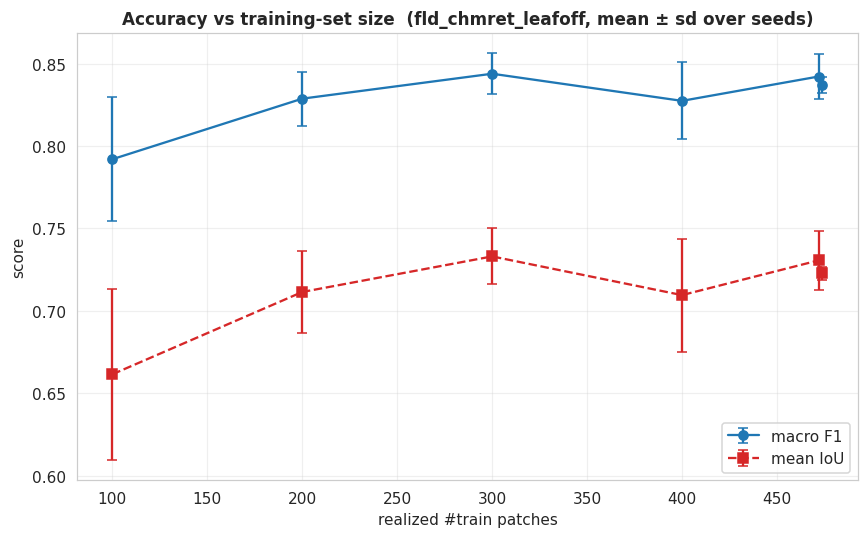

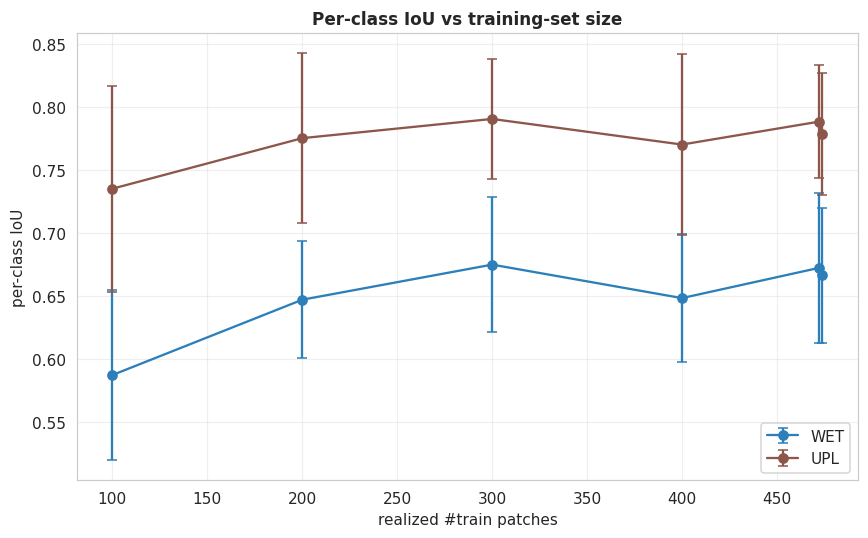

In [26]:
# Learning curve, mean ± sd over seeds, x = realized #train patches.
if pcurve.empty:
    print("No patch-curve cells under", PATCHCURVE_DIR, "- skipping section 6.")
else:
    ov = (pcurve.drop_duplicates(["level_sort", "seed"])
                .groupby("level_sort", as_index=False)
                .agg(train=("train_patches", "mean"),
                     mf1_m=("macro_f1", "mean"), mf1_s=("macro_f1", "std"),
                     miou_m=("mean_iou", "mean"), miou_s=("mean_iou", "std"))
                .sort_values("train"))
    pc = (pcurve.groupby(["level_sort", "class"], as_index=False)
                .agg(train=("train_patches", "mean"),
                     iou_m=("iou", "mean"), iou_s=("iou", "std")))

    # 6a · overall accuracy vs training-set size
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(ov["train"], ov["mf1_m"], yerr=ov["mf1_s"].fillna(0),
                marker="o", capsize=3, color="#1f77b4", label="macro F1")
    ax.errorbar(ov["train"], ov["miou_m"], yerr=ov["miou_s"].fillna(0),
                marker="s", linestyle="--", capsize=3, color="#d62728", label="mean IoU")
    ax.set_xlabel("realized #train patches"); ax.set_ylabel("score")
    ax.set_title(f"Accuracy vs training-set size  ({PC_CFG}, mean ± sd over seeds)")
    ax.legend()
    fig.tight_layout(); savefig(fig, "06_patchcurve_overall"); plt.show()

    # 6b · per-class IoU vs training-set size
    fig, ax = plt.subplots(figsize=(8, 5))
    for cls in CLASS_ORDER:
        s = pc[pc["class"] == cls].sort_values("train")
        if s.empty:
            continue
        ax.errorbar(s["train"], s["iou_m"], yerr=s["iou_s"].fillna(0),
                    marker="o", capsize=3, color=CLASS_COLORS.get(cls), label=cls)
    ax.set_xlabel("realized #train patches"); ax.set_ylabel("per-class IoU")
    ax.set_title("Per-class IoU vs training-set size"); ax.legend()
    fig.tight_layout(); savefig(fig, "06_patchcurve_per_class"); plt.show()

## 7 · Architecture comparison — U-Net vs UNet3+

UNet3+ (full-scale skips + deep supervision) vs the base-factorial U-Net on the
same config, **paired by seed** (same seed ⇒ same test patches). Both held at
bf64 / d5 for a fair comparison (plan §9, `run_arch_compare.sh`). The U-Net arm
is the base factorial's `Models/factorial_results/<config>/`.

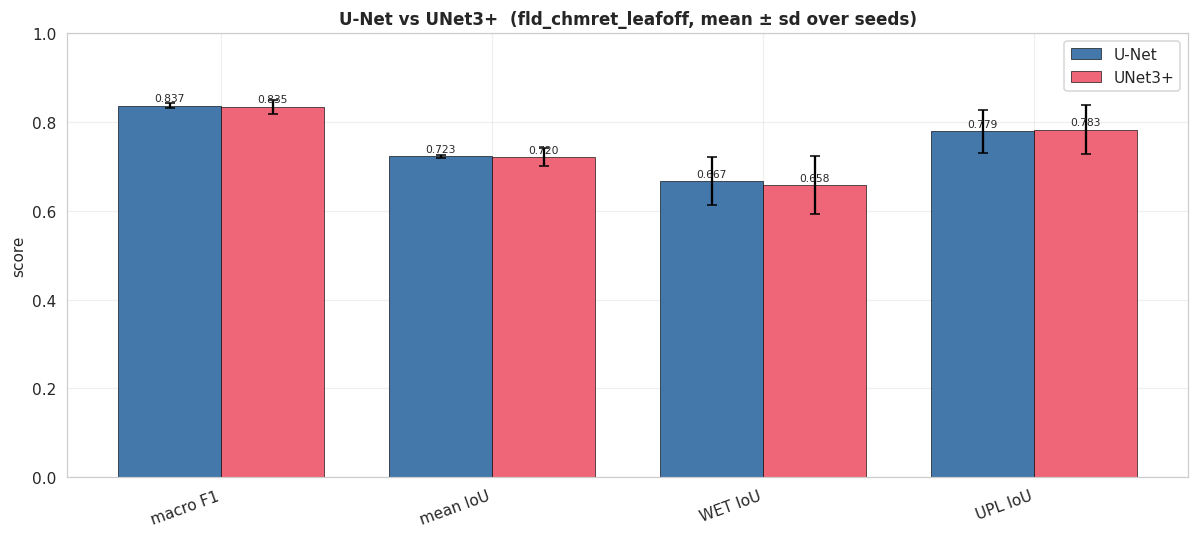

paired delta (UNet3+ - U-Net), mean over seeds:
d_macro_f1   -0.0024
d_mean_iou   -0.0025
d_iou_WET    -0.0088
d_iou_UPL     0.0038


In [27]:
# U-Net (base factorial) vs UNet3+ (results_arch), paired by seed.
ARCH_CFG = "fld_chmret_leafoff"

def load_arch(cell_dir, label):
    rows = []
    for seed_dir in sorted(Path(cell_dir).glob("seed*")):
        if not seed_dir.name[4:].isdigit():
            continue
        mfile = seed_dir / "metrics.json"
        if not mfile.exists():
            continue
        sc = _scores(json.loads(mfile.read_text()))   # unwrap v2 test_metrics
        row = {"arch": label, "seed": int(seed_dir.name[4:]),
               "macro_f1": sc.get("macro_f1"), "mean_iou": sc.get("mean_iou"),
               "overall_accuracy": sc.get("overall_accuracy")}
        for cls, cm in sc.get("per_class", {}).items():
            row[f"iou_{cls}"] = cm.get("iou")
        rows.append(row)
    return pd.DataFrame(rows)

unet   = load_arch(RESULTS_DIR / ARCH_CFG, "U-Net")
u3plus = load_arch(ARCH_DIR / f"{ARCH_CFG}_unet3plus", "UNet3+")

if unet.empty or u3plus.empty:
    print(f"arch-compare: missing cells (U-Net={len(unet)}, UNet3+={len(u3plus)}) - skipping section 7.")
else:
    metrics = ["macro_f1", "mean_iou"] + [f"iou_{c}" for c in CLASS_ORDER]
    labels  = ["macro F1", "mean IoU"] + [f"{c} IoU" for c in CLASS_ORDER]
    msd = lambda df, col: (df[col].mean(), df[col].std() if len(df) > 1 else 0.0)
    um = [msd(unet, m) for m in metrics]
    tm = [msd(u3plus, m) for m in metrics]
    x = np.arange(len(metrics)); w = 0.38
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(x - w/2, [v[0] for v in um], w, yerr=[v[1] for v in um], capsize=3,
           color="#4477aa", edgecolor="black", linewidth=0.4, label="U-Net")
    ax.bar(x + w/2, [v[0] for v in tm], w, yerr=[v[1] for v in tm], capsize=3,
           color="#ee6677", edgecolor="black", linewidth=0.4, label="UNet3+")
    for i, (a, b) in enumerate(zip(um, tm)):
        ax.text(i - w/2, a[0] + 0.005, f"{a[0]:.3f}", ha="center", va="bottom", fontsize=7)
        ax.text(i + w/2, b[0] + 0.005, f"{b[0]:.3f}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylabel("score"); ax.set_ylim(0, 1.0)
    ax.set_title(f"U-Net vs UNet3+  ({ARCH_CFG}, mean ± sd over seeds)"); ax.legend()
    fig.tight_layout(); savefig(fig, "07_arch_compare_bars"); plt.show()

    # Paired seed-mean deltas (UNet3+ - U-Net); mirrors arch_compare.csv.
    paired = unet.merge(u3plus, on="seed", suffixes=("_unet", "_u3p"))
    for m in metrics:
        paired[f"d_{m}"] = paired[f"{m}_u3p"] - paired[f"{m}_unet"]
    delta_cols = [f"d_{m}" for m in metrics]
    print("paired delta (UNet3+ - U-Net), mean over seeds:")
    print(paired[delta_cols].mean().round(4).to_string())
    paired[["seed"] + delta_cols].round(4)

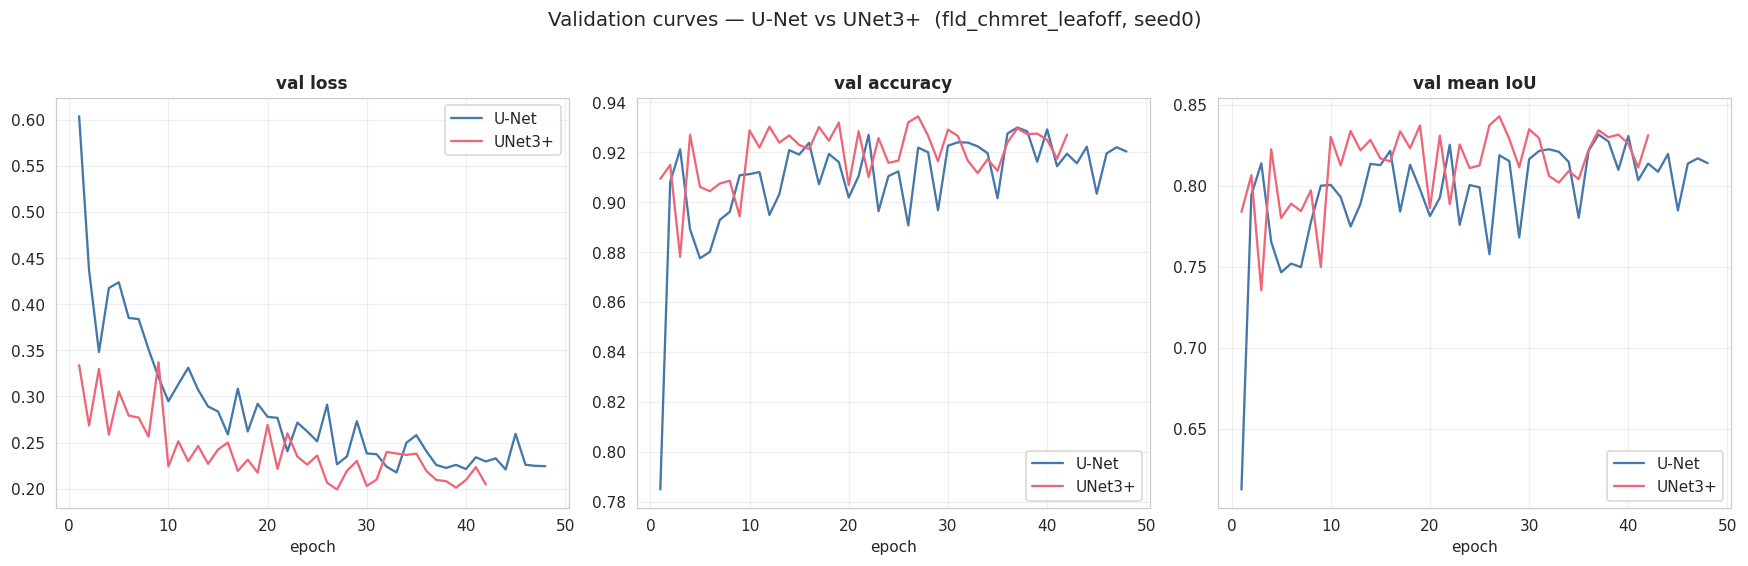

In [28]:
# Per-epoch validation curves, U-Net vs UNet3+ (representative seed). Reads the
# training_history_*.json each cell writes (per-epoch train/val loss/acc/IoU).
ARCH_SEED = 0

def load_history(cell_dir):
    hits = sorted(Path(cell_dir).glob("training_history_*.json"))
    return json.loads(hits[0].read_text()) if hits else None

h_unet = load_history(RESULTS_DIR / ARCH_CFG / f"seed{ARCH_SEED}")
h_u3p  = load_history(ARCH_DIR / f"{ARCH_CFG}_unet3plus" / f"seed{ARCH_SEED}")

if not h_unet or not h_u3p:
    print(f"arch val-curves: missing training_history for seed{ARCH_SEED} - skipping.")
else:
    panels = [("val_loss", "val loss"), ("val_accuracy", "val accuracy"),
              ("val_iou", "val mean IoU")]
    fig, axes = plt.subplots(1, len(panels), figsize=(16, 5))
    for ax, (key, title) in zip(axes, panels):
        for hist, label, color in [(h_unet, "U-Net", "#4477aa"),
                                    (h_u3p, "UNet3+", "#ee6677")]:
            y = hist.get(key, [])
            if y:
                ax.plot(range(1, len(y) + 1), y, color=color, label=label)
        ax.set_xlabel("epoch"); ax.set_title(title); ax.legend()
    fig.suptitle(f"Validation curves — U-Net vs UNet3+  ({ARCH_CFG}, seed{ARCH_SEED})",
                 y=1.02, fontsize=13)
    fig.tight_layout(); savefig(fig, "07_arch_val_curves"); plt.show()

## 8 · HUC inference — wetland prevalence

Moved to **`dl_10b_huc_inference_viz.ipynb`** (data-heavy companion). That
section reads the multi-GB per-HUC GeoTIFFs in `Data/HUC_DL_Predictions/`,
which are gitignored and rsync'd separately — keeping this notebook syncable
through git from small CSV/JSON only.


## 9 · Cross-mode comparison — binary vs multiclass

This section reads **both** modes' aggregated outputs (independent of the `MODE`
selector above) to answer: *does training natively in binary beat collapsing a
multiclass model to wetland-vs-upland?* Two views that are genuinely apples-to-
apples across modes:

- **Upland (UPL)** — the identical class in both modes, so UPL IoU/recall are
  compared directly with mean ± sd over seeds (from each mode's
  `factorial_long.csv`).
- **Wetland (WET)** — for the multiclass models we **collapse the seed-mean
  confusion matrix** (EMW/FSW/SSW → WET) to a 2×2 and recompute WET IoU/recall,
  then compare against the natively-binary WET. This is the fair "collapse a
  4-class model" baseline for the binary head. (Point estimate from the mean CM;
  macro-F1 across modes is *not* comparable — different class counts — so it is
  deliberately omitted.)

The **label gradient** (`nwi → nwiextra → nwifield → flddeg → fld`) is shown in
both modes so the quantity-vs-correctness story can be read per mode. Outputs
are written to `factorial_results_v2/analysis/` (the mode-less version root) as
`cross_mode_summary.csv`.


In [29]:
# --- Cross-mode comparison: reads BOTH modes' analysis dirs directly ---------
MC_ANALYSIS  = _FACT_ROOT / "multiclass" / "analysis"
BIN_ANALYSIS = _FACT_ROOT / "binary" / "analysis"
XMODE_DIR    = _FACT_ROOT / "analysis"            # mode-less version root
XMODE_DIR.mkdir(parents=True, exist_ok=True)

def _load_cm(analysis_dir, cfg):
    f = analysis_dir / "confusion_mean" / f"{cfg}.csv"
    return pd.read_csv(f, index_col=0) if f.exists() else None

def _iou_recall(cm, cls):
    """(IoU, recall) for one class from a confusion matrix (true rows x pred cols)."""
    names = list(cm.index)
    if cls not in names:
        return (np.nan, np.nan)
    M = cm.values.astype(float)
    i = names.index(cls)
    tp = M[i, i]; fn = M[i, :].sum() - tp; fp = M[:, i].sum() - tp
    iou = tp / (tp + fn + fp) if (tp + fn + fp) > 0 else np.nan
    rec = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    return (iou, rec)

def _collapse_wet(cm):
    """Collapse a multiclass CM (EMW/FSW/SSW/UPL) to 2x2 WET/UPL by summing the
    wetland rows and columns."""
    remap = {c: ("WET" if c in ("EMW", "FSW", "SSW") else c) for c in cm.index}
    g = cm.rename(index=remap, columns=remap)
    g = g.groupby(level=0).sum().T.groupby(level=0).sum().T
    return g.reindex(index=["WET", "UPL"], columns=["WET", "UPL"])

def _upl_meansd(analysis_dir):
    """UPL IoU/recall mean & sd over seeds, per config, from factorial_long.csv."""
    f = analysis_dir / "factorial_long.csv"
    if not f.exists():
        return {}
    df = pd.read_csv(f)
    upl = df[df["class"] == "UPL"]
    out = {}
    for cfg, s in upl.groupby("config"):
        out[cfg] = dict(iou_m=s["iou"].mean(), iou_s=s["iou"].std(),
                        rec_m=s["recall"].mean(), rec_s=s["recall"].std())
    return out

if not (MC_ANALYSIS / "confusion_mean").is_dir() or not (BIN_ANALYSIS / "confusion_mean").is_dir():
    print("Cross-mode needs BOTH modes aggregated. Run, on the CPU node:")
    print("  RESULTS_DIR=Models/factorial_results_v2/multiclass SEEDS=\"0 1 2 3 4\" Shell_Scripts/run_aggregate.sh")
    print("  RESULTS_DIR=Models/factorial_results_v2/binary     SEEDS=\"0 1 2 3 4\" Shell_Scripts/run_aggregate.sh")
    print(f"missing: multiclass={MC_ANALYSIS/'confusion_mean'} binary={BIN_ANALYSIS/'confusion_mean'}")
    xmode = pd.DataFrame()
else:
    upl_mc, upl_bin = _upl_meansd(MC_ANALYSIS), _upl_meansd(BIN_ANALYSIS)
    shared = [c for c in CONFIG_ORDER
              if _load_cm(MC_ANALYSIS, c) is not None and _load_cm(BIN_ANALYSIS, c) is not None]
    rows = []
    for cfg in shared:
        wet_mc_i,  wet_mc_r  = _iou_recall(_collapse_wet(_load_cm(MC_ANALYSIS, cfg)), "WET")
        wet_bin_i, wet_bin_r = _iou_recall(_load_cm(BIN_ANALYSIS, cfg), "WET")
        u_mc  = upl_mc.get(cfg, {}); u_bin = upl_bin.get(cfg, {})
        rows.append({
            "config": cfg,
            "WET_iou_mc_collapsed": wet_mc_i, "WET_iou_binary": wet_bin_i,
            "WET_iou_delta(bin-mc)": wet_bin_i - wet_mc_i,
            "WET_recall_mc_collapsed": wet_mc_r, "WET_recall_binary": wet_bin_r,
            "UPL_iou_mc": u_mc.get("iou_m"), "UPL_iou_mc_sd": u_mc.get("iou_s"),
            "UPL_iou_binary": u_bin.get("iou_m"), "UPL_iou_binary_sd": u_bin.get("iou_s"),
            "UPL_iou_delta(bin-mc)": (u_bin.get("iou_m", np.nan) - u_mc.get("iou_m", np.nan)),
        })
    xmode = pd.DataFrame(rows).set_index("config")
    xmode.to_csv(XMODE_DIR / "cross_mode_summary.csv")
    print(f"cross-mode summary -> {XMODE_DIR/'cross_mode_summary.csv'}  ({len(xmode)} configs)")
    try:
        display(xmode.round(4))
    except NameError:
        print(xmode.round(4).to_string())


cross-mode summary -> /ibstorage/anthony/NYS_Wetlands_DL/Models/factorial_results_v2/analysis/cross_mode_summary.csv  (8 configs)


,WET_iou_mc_collapsed,WET_iou_binary,WET_iou_delta(bin-mc),WET_recall_mc_collapsed,WET_recall_binary,UPL_iou_mc,UPL_iou_mc_sd,UPL_iou_binary,UPL_iou_binary_sd,UPL_iou_delta(bin-mc)
config,,,,,,,,,,
fld_nolidar_leafon,0.6328,0.6463,0.0135,0.8022,0.8002,0.7611,0.0664,0.7821,0.0451,0.0210
fld_nolidar_leafoff,0.6473,0.6673,0.0200,0.8583,0.8263,0.7600,0.0600,0.7911,0.0455,0.0311
fld_chmret_leafon,0.6424,0.6168,-0.0255,0.8371,0.7366,0.7621,0.0518,0.7786,0.0600,0.0165
fld_chmret_leafoff,0.6538,0.6669,0.0131,0.8475,0.8532,0.7675,0.0616,0.7788,0.0482,0.0113
nwi_chmret_leafoff,0.5856,0.6125,0.0269,0.7388,0.7405,0.7498,0.0519,0.7689,0.0654,0.0191
nwiextra_chmret_leafoff,0.6256,0.6366,0.0110,0.8352,0.8139,0.7486,0.0541,0.7671,0.0533,0.0184
nwifield_chmret_leafoff,0.6591,0.6681,0.0089,0.8700,0.8584,0.7672,0.0518,0.7748,0.0693,0.0076
flddeg_chmret_leafoff,0.6340,0.6744,0.0404,0.8274,0.8514,0.7530,0.0742,0.7862,0.0599,0.0332


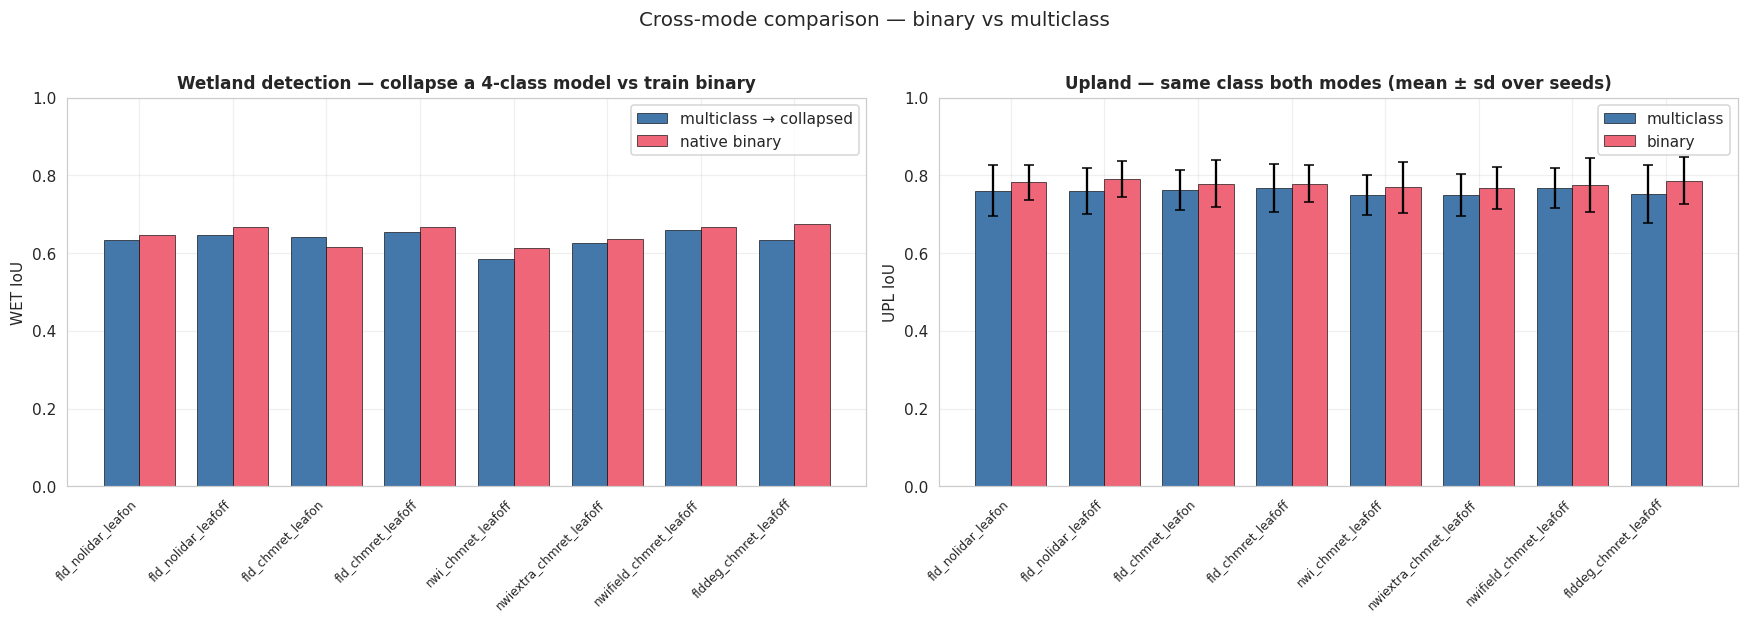

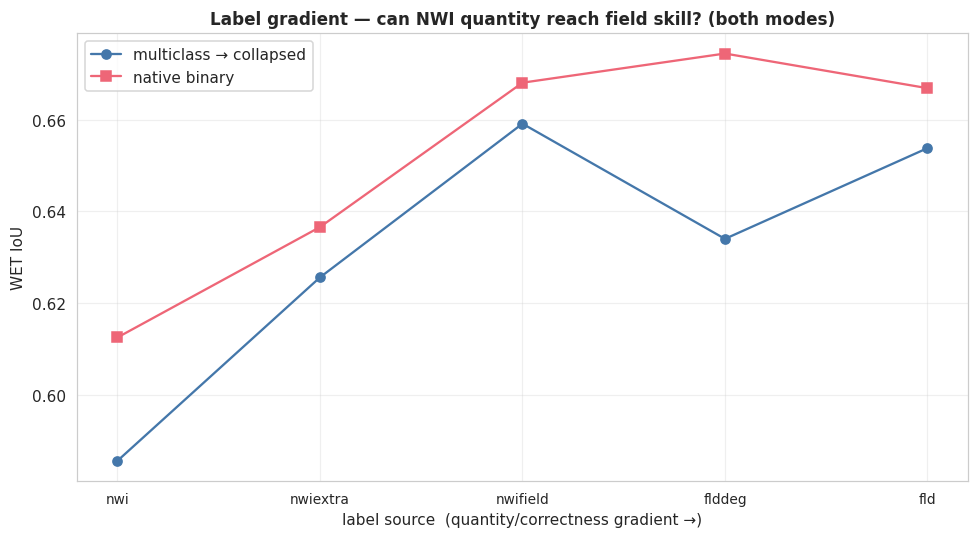

In [30]:
# --- Cross-mode figures: WET (collapsed-mc vs binary), UPL, and label gradient --
if xmode.empty:
    print("No cross-mode table (aggregate both modes first) — skipping section 9 figures.")
else:
    cfgs = list(xmode.index)
    x = np.arange(len(cfgs)); w = 0.38

    fig, (axW, axU) = plt.subplots(1, 2, figsize=(16, 5.5))
    # WET IoU: multiclass-collapsed vs native binary (point estimates from mean CM).
    axW.bar(x - w/2, xmode["WET_iou_mc_collapsed"], w, color="#4477aa",
            edgecolor="black", linewidth=0.4, label="multiclass → collapsed")
    axW.bar(x + w/2, xmode["WET_iou_binary"], w, color="#ee6677",
            edgecolor="black", linewidth=0.4, label="native binary")
    axW.set_xticks(x); axW.set_xticklabels(cfgs, rotation=45, ha="right", fontsize=8)
    axW.set_ylabel("WET IoU"); axW.set_ylim(0, 1.0)
    axW.set_title("Wetland detection — collapse a 4-class model vs train binary")
    axW.legend()
    # UPL IoU: identical class in both modes, so show mean ± sd over seeds.
    axU.bar(x - w/2, xmode["UPL_iou_mc"], w, yerr=xmode["UPL_iou_mc_sd"].fillna(0),
            capsize=3, color="#4477aa", edgecolor="black", linewidth=0.4, label="multiclass")
    axU.bar(x + w/2, xmode["UPL_iou_binary"], w, yerr=xmode["UPL_iou_binary_sd"].fillna(0),
            capsize=3, color="#ee6677", edgecolor="black", linewidth=0.4, label="binary")
    axU.set_xticks(x); axU.set_xticklabels(cfgs, rotation=45, ha="right", fontsize=8)
    axU.set_ylabel("UPL IoU"); axU.set_ylim(0, 1.0)
    axU.set_title("Upland — same class both modes (mean ± sd over seeds)")
    axU.legend()
    fig.suptitle("Cross-mode comparison — binary vs multiclass", y=1.02, fontsize=13)
    fig.tight_layout(); savefig(fig, "09_cross_mode_wet_upl"); plt.show()

    # Label gradient: quantity-vs-correctness across label sources, both modes.
    GRADIENT = ["nwi_chmret_leafoff", "nwiextra_chmret_leafoff",
                "nwifield_chmret_leafoff", "flddeg_chmret_leafoff", "fld_chmret_leafoff"]
    grad = [c for c in GRADIENT if c in xmode.index]
    if len(grad) >= 2:
        gx = np.arange(len(grad))
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(gx, xmode.loc[grad, "WET_iou_mc_collapsed"], marker="o",
                color="#4477aa", label="multiclass → collapsed")
        ax.plot(gx, xmode.loc[grad, "WET_iou_binary"], marker="s",
                color="#ee6677", label="native binary")
        ax.set_xticks(gx)
        ax.set_xticklabels([c.replace("_chmret_leafoff", "") for c in grad], fontsize=9)
        ax.set_ylabel("WET IoU")
        ax.set_xlabel("label source  (quantity/correctness gradient →)")
        ax.set_title("Label gradient — can NWI quantity reach field skill? (both modes)")
        ax.legend()
        fig.tight_layout(); savefig(fig, "09_cross_mode_label_gradient"); plt.show()
    else:
        print("Label-gradient plot needs ≥2 of", GRADIENT, "— have", grad)
